# [1교시]

---

# 순환 신경망(RNN) 
## Part 1: 개요 

## 1장. 왜 RNN이 필요한가?

### 1.1 기존 신경망(CNN/MLP)의 한계

지금까지 우리가 배운 일반적인 신경망(Feedforward Neural Network, CNN 등)은 다음과 같은 구조를 가집니다:

```
입력 (고정 크기) → 은닉층 → 출력 (고정 크기)
```

예를 들어, 이미지 분류 문제에서:
- **입력:** 224×224×3 크기의 이미지 (고정)
- **출력:** 1000개 클래스 중 하나 (고정)

이런 구조는 **입출력 크기가 고정**되어 있어야 한다는 제약이 있습니다.

#### 구체적 예시: MLP로 감성 분석을 시도한다면?

```
리뷰 A: "좋아요"           → 단어 1개
리뷰 B: "이 영화 정말 좋아요" → 단어 4개  
리뷰 C: "배우 연기도 좋고 스토리도 탄탄해서 정말 재미있게 봤습니다" → 단어 8개
```

MLP는 입력 크기가 고정이므로, 예를 들어 **최대 5개 단어**로 설정하면:

| 리뷰 | MLP 입력 (5칸 고정) | 문제점 |
|------|---------------------|--------|
| A | `[좋아요, 0, 0, 0, 0]` | 패딩이 너무 많아 정보 희석 |
| B | `[이, 영화, 정말, 좋아요, 0]` | 괜찮아 보이지만... |
| C | `[배우, 연기도, 좋고, 스토리도, 탄탄해서]` |  "재미있게 봤습니다" 잘림! |

> **결론:** 고정 크기 입력은 짧은 문장엔 낭비, 긴 문장엔 정보 손실이 발생합니다.

### 1.2 실세계에서 만나는 가변 길이 문제들

| 문제 유형 | 입력 | 출력 | 예시 |
|----------|------|------|------|
| 이미지 캡셔닝 | 이미지 1장 (고정) | 문장 (가변) | "고양이가 소파에 앉아 있다" |
| 감성 분석 | 문장 (가변) | 긍정/부정 (고정) | "이 영화 최고다" → 긍정 |
| 기계 번역 | 영어 문장 (가변) | 한국어 문장 (가변) | "Hello" → "안녕하세요" |
| 비디오 분류 | 프레임 시퀀스 (가변) | 매 프레임 레이블 (가변) | 달리기, 걷기, 점프... |

> **핵심:** CNN은 입출력 크기가 고정되어 있어, 위와 같은 **가변 길이 시퀀스** 문제를 처리할 수 없습니다.

####  왜 고정 크기가 문제인가?

**예시 1: 감성 분석에서 CNN을 사용하려면?**
- 만약 CNN의 입력이 정확히 100개 단어로 고정되어야 한다면?
  - 문장 A: "이 영화 최고" (4단어) → **96개의 패딩(0)을 추가해야 함**
  - 문장 B: "이 영화는 정말 훌륭하고 최고의 작품이며 감동적이고 모든 것이 완벽하다" (15단어) → 85개 패딩
  - 문장 C: "재미없다" (2단어) → 98개 패딩

→ **문제점:** 의미 있는 정보(단어)는 4%인데 96%는 패딩 → 비효율적

**예시 2: 기계 번역에서의 문제**
- 영어 → 한국어 번역 시
  - "Hello" (1단어) → "안녕하세요" (1단어)
  - "How are you?" (3단어) → "어떻게 지내세요?" (2단어)
  - 같은 의미도 언어마다 길이가 다름 → 고정 크기로는 불가능

####  RNN이 해결하는 방법

**재귀적 구조(Recurrence)** 를 이용하여:
- 시퀀스의 길이와 **무관하게** 동작
- 한 번에 한 단계(타임스텝)씩 처리 → **메모리 효율적**
- 이전 정보를 "기억"하는 **은닉 상태**를 유지

### 1.3 RNN이 제공하는 유연성

![Figure 1: RNN 아키텍처 유형](images/types.png)

> ** 이미지 설명 (types.png):**  
> 5가지 RNN 아키텍처를 도식화한 그림입니다.  
> - 왼쪽부터 **one-to-one**(빨간→초록 하나씩), **one-to-many**(빨간 하나→초록 여러 개), **many-to-one**(빨간 여러 개→초록 하나), **many-to-many(지연)**(빨간 여러 개→초록 여러 개, 인코더-디코더), **many-to-many(동기)**(빨간과 초록이 동시에 진행)  
> - **빨간색 블록** = 입력, **초록색 블록** = 출력, **가운데 파란색 블록** = RNN 은닉 상태

RNN은 다음과 같이 다양한 입출력 구조를 지원합니다:

| 모델 유형 | 설명 | 대표 응용 |
|----------|------|----------|
| **일대일 (One-to-One)** | 고정 입력 → 고정 출력 | 일반 이미지 분류 (vanilla NN) |
| **일대다 (One-to-Many)** | 고정 입력 → 시퀀스 출력 | 이미지 캡셔닝 |
| **다대일 (Many-to-One)** | 시퀀스 입력 → 고정 출력 | 감성 분석, 행동 인식 |
| **다대다 (Many-to-Many) ①** | 시퀀스 입력 → 시퀀스 출력 (지연) | 기계 번역 |
| **다대다 (Many-to-Many) ②** | 시퀀스 입력 → 시퀀스 출력 (동기) | 비디오 프레임 분류 |

####  각 유형의 한국어 데이터 예시

**① 일대다 (One-to-Many) — 이미지 캡셔닝:**
```
입력:  [고양이 사진 텐서]
출력: "고양이" → "가" → "소파에" → "앉아" → "있다"
```

**② 다대일 (Many-to-One) — 감성 분석:**
```
입력: "이" → "영화" → "정말" → "재미있다"
출력: 긍정 (1)
```

**③ 다대다 (Many-to-Many) — 기계 번역:**
```
입력:  "나" → "는" → "학생" → "이다"
출력:  "I"  → "am" → "a"   → "student"
```

> **RNN의 핵심 아이디어:** 모든 타임스텝에서의 예측이, 그 이전까지의 **모든 타임스텝의 정보를 반영**합니다.

---

## 2장. RNN의 기본 구조

### 2.1 블랙박스로 이해하는 RNN

![Figure 2: RNN 블랙박스](images/rnn_blackbox.png)

RNN을 처음 이해할 때 "블랙박스"로 생각해 봅시다:

- RNN 내부에는 **내부 상태(Internal State)** 가 존재합니다
- 시퀀스가 입력될 때마다 이 내부 상태가 **업데이트** 됩니다
- 이 내부 상태를 **은닉 상태(Hidden State)**, $h$ 로 표기합니다

####  직관적 비유: "기억"을 갖는 상자

RNN을 **기억력이 있는 상자**로 생각해봅시다:

```
시간 1초: 
  입력: "안녕"
  기억 상태: 비어있음 (h_0 = 0)
  ↓
  [상자 처리] → 새로운 기억 생성: h_1
  출력: 첫 번째 응답

시간 2초:
  입력: "하세"  
  기억 상태: 이전의 기억 h_1 ← ★ 이전 정보 기억!
  ↓
  [상자 처리] → 기억 업데이트: h_2
  출력: 두 번째 응답 (첫 번째 입력도 고려함)

시간 3초:
  입력: "요"
  기억 상태: h_2 ← ★ "안녕" + "하세" 정보 포함
  ↓
  [상자 처리] → h_3
  출력: 세 번째 응답 (모든 이전 입력 정보 포함)
```

**구체적 예시:**
- 일반 신경망: 각 단계마다 기억 없음 → "요"만 보고 응답
- **RNN**: 모든 이전 입력을 기억 → "안녕하세요"의 흐름을 이해

####  은닉 상태가 담는 정보

은닉 상태 $h_t$는:
- 현재까지 본 모든 입력 정보의 **압축된 요약**
- 크기 $n$ (예: $n=3$)의 벡터
- 이 정보를 이용해 다음 예측을 함

### 2.2 RNN 펼치기 (Unrolling)

![Figure 2b: 펼친 RNN](images/unrolledRNN.png)

시간축으로 RNN을 펼쳐보면 위 그림과 같습니다. 각 타임스텝 $t$ 에서:

1. **입력:** 현재 입력 $x_t$ + 이전 은닉 상태 $h_{t-1}$
2. **처리:** 동일한 가중치 $W$ 를 적용하는 함수 $f_W$
3. **출력:** 현재 은닉 상태 $h_t$ (+ 필요시 출력 $y_t$)

> **핵심 포인트:** 모든 타임스텝에서 **동일한 가중치 $W$** 를 공유합니다. 이 때문에 입력 시퀀스 길이에 무관하게 작동할 수 있습니다!

#### 📖 구체적 예시: "hello" 문자열 처리

문자열 "hello"를 문자 단위로 처리하는 예:

```
시간 t=0:
  h_0 = [0, 0, 0]  (초기 상태: 영벡터)

시간 t=1 (입력: "h"):
  입력 x_1 = "h"
  은닉 상태 h_1 = f_W(h_0, x_1) = "h"를 처리한 상태
  
시간 t=2 (입력: "e"):  
  입력 x_2 = "e"
  은닉 상태 h_2 = f_W(h_1, x_2) = "h"와 "e" 모두의 정보 포함
  
시간 t=3 (입력: "l"):
  입력 x_3 = "l"  
  은닉 상태 h_3 = f_W(h_2, x_3) = "h", "e", "l" 모두의 정보 포함

... 계속
```

####  왜 "같은 가중치"를 사용할까?

**일반 신경망 vs RNN:**

```
일반 신경망:
  층 1 가중치: W1 → 층 2 가중치: W2 → 층 3 가중치: W3
  (각 층마다 다른 가중치)

RNN (펼친 형태):
  t=1 가중치: W → t=2 가중치: W → t=3 가중치: W
  (모든 시간 단계에서 "같은" 가중치 W 재사용)
```

**장점:**
- 시퀀스 길이와 무관하게 동작
- 파라미터 개수가 적음 (메모리 효율)
- 어떤 길이의 입력도 처리 가능

### 2.3 Vanilla RNN이란? (RNN의 기본형)

####  "Vanilla"는 무엇인가?

**"Vanilla"의 의미:**
- 프로그래밍에서: **가장 기본적인, 꾸미지 않은, 순수한 형태**
- 아이스크림: "바닐라 맛" = 기본 맛 (가장 단순한 맛)
- 딥러닝: "Vanilla RNN" = **가장 기본적인 RNN**

#### 📊 RNN의 여러 변형들

학자들이 "기울기 소실" 문제를 해결하기 위해 여러 RNN 변형을 만들었습니다:

| 종류 | 설명 | 특징 | 발표 연도 |
|------|------|------|----------|
| **Vanilla RNN** | 가장 기본적인 RNN | 간단함, 하지만 기울기 소실 문제 | 1997 |
| **LSTM** | Long Short-Term Memory | 기울기 소실 문제 해결, 복잡함 | 1997 |
| **GRU** | Gated Recurrent Unit | LSTM보다 간단, 거의 같은 성능 | 2014 |
| **Bidirectional RNN** | 양방향 처리 | 과거와 미래 정보 모두 사용 | 2005 |

####  Vanilla RNN vs LSTM vs GRU 비교

```
Vanilla RNN (기본형):
  h_t = tanh(W_hh @ h_{t-1} + W_xh @ x_t)
  구조: 단순
  파라미터: 적음
  학습 속도: 빠름
  문제: 기울기 소실 (긴 시퀀스에서 약함)

LSTM (정교한 형태):
  h_t = (복잡한 게이트 계산)
  구조: 복잡 (Cell state, 여러 게이트)
  파라미터: 많음 (Vanilla의 약 4배)
  학습 속도: 느림
  장점: 기울기 소실 없음, 긴 의존성 학습 가능

GRU (LSTM의 간단한 버전):
  h_t = (LSTM과 유사하지만 더 간단)
  구조: 중간 정도 (LSTM보다 간단)
  파라미터: 중간 (Vanilla의 약 3배)
  학습 속도: 중간
  장점: LSTM과 비슷한 성능, 계산량 적음
```

####  Vanilla RNN?

1. **기초 개념 이해**
   - 은닉 상태, 재귀 구조 등 기본 개념 파악
   - LSTM/GRU는 Vanilla의 기반 위에 만들어짐

2. **역사적 순서**
   - Vanilla RNN (1997) → LSTM (1997) → GRU (2014)
   - 역사적으로 Vanilla가 먼저 나옴

3. **문제 이해**
   - Vanilla의 "기울기 소실" 문제를 먼저 알아야
   - LSTM이 왜 필요한지 이해 가능

4. **코드 간결성**
   - Vanilla: 약 10줄
   - LSTM: 약 50줄
   - 간단한 것부터 학습하는 원칙

### 2.4 수식으로 이해하는 RNN

#### 재귀 공식 (Recurrence Formula)

$$\boxed{h_t = f_W(h_{t-1}, x_t)}$$

**의미:** 현재 은닉 상태는 **이전 상태**와 **현재 입력**에만 의존

**기호 설명:**
| 기호 | 의미 | 차원 | 예시 |
|------|------|------|------|
| $h_t$ | 타임스텝 $t$ 에서의 **은닉 상태 벡터** | $\mathbb{R}^n$ | [0.5, -0.3, 0.8] |
| $h_{t-1}$ | 이전 타임스텝의 **은닉 상태 벡터** | $\mathbb{R}^n$ | [0.2, -0.1, 0.5] |
| $x_t$ | 타임스텝 $t$ 에서의 **입력 벡터** | $\mathbb{R}^d$ | [1, 0, 0, 0] (one-hot) |
| $f_W$ | 가중치 $W$ 를 가진 **고정 함수** | - | $\tanh(\cdot)$ |
| $W$ | RNN의 **학습 가능한 가중치** | - | 수정됨 |

#### 핵심 아이디어: Markov 성질

$$h_t \text{는 } h_{t-1} \text{과 } x_t \text{에만 의존}$$

→ 이전의 모든 정보가 $h_{t-1}$에 **압축**되어 있다!

**예시:**
```
타임스텝 1: h_1 = f_W(h_0, x_1)           // 입력 1만 본 정보
타임스텝 2: h_2 = f_W(h_1, x_2)           // 입력 1,2의 정보 (h_1에 압축)
타임스텝 3: h_3 = f_W(h_2, x_3)           // 입력 1,2,3의 정보 (h_2에 압축)
타임스텝 4: h_4 = f_W(h_3, x_4)           // 입력 1,2,3,4의 정보 (h_3에 압축)
```

**비유:** 은닉 상태는 "뇌의 기억력" 같은 역할
- 모든 이전 대화 내용을 완벽하게 기억
- 하지만 메모리 제약으로 **중요한 정보만 압축**

### 2.5 Vanilla RNN 상세 수식

![Figure: Vanilla RNN 수식 1](images/vanilla_rnn_mformula_1.png)

가장 기본적인 형태인 **Vanilla RNN**의 은닉 상태 업데이트 수식:

$$\boxed{h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t)}$$

**기호 설명:**
| 기호 | 의미 | 차원 |
|------|------|------|
| $W_{hh}$ | **은닉→은닉** 가중치 행렬 | $\mathbb{R}^{n \times n}$ |
| $W_{xh}$ | **입력→은닉** 가중치 행렬 | $\mathbb{R}^{n \times d}$ |
| $\tanh$ | 쌍곡선 탄젠트 활성화 함수, 출력 범위: $(-1, 1)$ | - |

####  계산 과정 - 상세 분석

**단계별 연산:**

| 단계 | 연산 | 차원 | 설명 |
|------|------|------|------|
| 1 | $x_t$ 준비 | $(d, 1)$ | 현재 입력 (원-핫 벡터) |
| 2 | $W_{xh} \cdot x_t$ | $(n, 1)$ | 입력을 은닉 공간으로 변환 |
| 3 | $h_{t-1}$ 준비 | $(n, 1)$ | 이전 은닉 상태 |
| 4 | $W_{hh} \cdot h_{t-1}$ | $(n, 1)$ | 이전 상태를 새 은닉 공간으로 변환 |
| 5 | $W_{xh} x_t + W_{hh} h_{t-1}$ | $(n, 1)$ | **두 정보의 합산** (현재 + 이전) |
| 6 | $\tanh(\cdot)$ 적용 | $(n, 1)$ | **활성화** → $h_t$ 생성 |

####  구체적 수치 예시

**설정:** 
- 입력 크기: $d = 4$ (어휘: h, e, l, o)
- 은닉 크기: $n = 3$

**초기값 (t=1):**
- 입력: $x_1 = [1, 0, 0, 0]^T$ (문자 "h")
- 이전 상태: $h_0 = [0, 0, 0]^T$ (초기화)

**가중치 (학습 후):**
$$W_{xh} = \begin{pmatrix} 0.2 & -0.1 & 0.3 & 0.1 \\ 0.5 & 0.2 & -0.2 & 0.4 \\ -0.3 & 0.4 & 0.1 & -0.2 \end{pmatrix}, \quad
W_{hh} = \begin{pmatrix} 0.1 & 0.2 & -0.1 \\ -0.2 & 0.3 & 0.1 \\ 0.4 & -0.1 & 0.2 \end{pmatrix}$$

**계산:**
$$W_{xh} \cdot x_1 = \begin{pmatrix} 0.2 \\ 0.5 \\ -0.3 \end{pmatrix}, \quad
W_{hh} \cdot h_0 = \begin{pmatrix} 0 \\ 0 \\ 0 \end{pmatrix}$$

$$z_1 = W_{xh} x_1 + W_{hh} h_0 = \begin{pmatrix} 0.2 \\ 0.5 \\ -0.3 \end{pmatrix}$$

$$h_1 = \tanh\begin{pmatrix} 0.2 \\ 0.5 \\ -0.3 \end{pmatrix} = \begin{pmatrix} 0.197 \\ 0.462 \\ -0.291 \end{pmatrix}$$

####  다음 타임스텝 (t=2, 입력 "e")

- 입력: $x_2 = [0, 1, 0, 0]^T$
- 이전 상태: $h_1 = [0.197, 0.462, -0.291]^T$ ← **이전 정보 포함!**

$$z_2 = W_{xh} x_2 + W_{hh} h_1 = \begin{pmatrix} -0.1 \\ 0.2 \\ 0.4 \end{pmatrix} + \begin{pmatrix} 0.069 \\ 0.063 \\ 0.065 \end{pmatrix} = \begin{pmatrix} -0.031 \\ 0.263 \\ 0.465 \end{pmatrix}$$

$$h_2 = \tanh(z_2) = \begin{pmatrix} -0.031 \\ 0.256 \\ 0.433 \end{pmatrix}$$

** 중요:** $h_2$는 "e"뿐만 아니라 $h_1$을 통해 "h"의 정보도 포함!

#### tanh 함수 특성

$$\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$$

- **출력 범위:** $(-1, +1)$ → 활성화된 벡터가 과도하게 커지지 않음
- **미분:** $\tanh'(z) = 1 - \tanh^2(z)$
- **미분 범위:** $(0, 1]$ (최대값 1)
  - $z = 0$일 때: $\tanh'(0) = 1$ (최대 기울기)
  - $z = \pm 2$일 때: $\tanh'(\pm 2) \approx 0.07$ (매우 작음)

**시각화:**
```
  tanh(z) 함수                          tanh'(z) 미분값
                                    
  +1.0 ┤          ............       1.0 ┤
       │        ··                       │
  +0.5 ┤      ·                    0.75 ┤
       │     ·                          │
   0.0 ┤····                       0.5 ┤        ·  ·
       │   ·                            │      ·      ·
  -0.5 ┤  ·                       0.25 ┤    ·          ·
       │ ·                              │  ·              ·
  -1.0 ┤·                          0.0 ┤·                  ·
       └──────────────────             └──────────────────
       -4  -2   0   +2  +4             -4  -2   0   +2  +4
              z 값                             z 값
```

**주요 입력값에 대한 tanh 출력 및 미분값:**

| $z$ | $\tanh(z)$ | $\tanh'(z)$ | 해석 |
|-----|-----------|-------------|------|
| -3.0 | -0.995 | **0.010** | 포화 → 기울기 거의 소실  |
| -2.0 | -0.964 | **0.071** | 포화 근접 |
| -1.0 | -0.762 | 0.420 | 중간 영역 |
| 0.0 | 0.000 | **1.000** | 최대 기울기  |
| 1.0 | 0.762 | 0.420 | 중간 영역 |
| 2.0 | 0.964 | **0.071** | 포화 근접 |
| 3.0 | 0.995 | **0.010** | 포화 → 기울기 거의 소실  |

- **$|z|$가 작을 때:** 기울기가 크다 (학습 잘 됨)
- **$|z|$가 클 때:** 기울기가 거의 0 (학습 안 됨)  **기울기 소실 문제**


### 2.6 출력 생성 수식

![Figure: Vanilla RNN 수식 2](images/vanilla_rnn_mformula_2.png)

은닉 상태 $h_t$ 로부터 출력 $y_t$ 를 생성:

$$\boxed{y_t = W_{hy} h_t}$$

**기호 설명:**
| 기호 | 의미 | 차원 |
|------|------|------|
| $W_{hy}$ | **은닉→출력** 가중치 행렬 | $\mathbb{R}^{k \times n}$ |
| $y_t$ | 타임스텝 $t$ 의 **출력 벡터** (로짓) | $\mathbb{R}^k$ |

####  출력의 의미: "로짓(Logit)"

$y_t$는 **확률이 아님** → 단지 각 클래스의 **상대적 점수**일 뿐

**예시:**
```
은닉 상태: h_1 = [0.197, 0.462, -0.291]

W_hy @ h_1 = y_1 = [1.0, 2.2, -3.0, 4.1]  ← 로짓값
```

| 문자 | 로짓 점수 | 의미 |
|------|-----------|------|
| "h" | 1.0 | 보통 (중간) |
| "e" | **2.2** | **높음** (가능성 높음) |
| "l" | -3.0 | 매우 낮음 (거의 불가능) |
| "o" | 4.1 | 가장 높음 (가장 가능성 높음) |

→ **소프트맥스**를 적용하면 확률로 변환됨 (Part 2에서 상세히 다룸)

####  왜 선형 변환만 사용할까?

출력층에서 **활성화 함수를 사용하지 않는** 이유:
- 은닉 상태는 이미 $(-1, 1)$ 범위로 정규화됨
- 출력은 **비정규화된 확률 점수(로짓)**로 남겨두기
- 소프트맥스와 크로스 엔트로피 손실과 결합하여 수치 안정성 향상

## 3장. Vanilla RNN 전체 동작 요약

전체 파라미터는 단 **세 개의 가중치 행렬**:

$$W = \{W_{xh},\ W_{hh},\ W_{hy}\}$$

#### 파라미터 수 계산

"hello" 예제 기준 ($d=4, n=3, k=4$):

| 가중치 | 차원 | 파라미터 수 | 역할 |
|--------|------|------------|------|
| $W_{xh}$ | $3 \times 4$ | 12개 | 입력 → 은닉 |
| $W_{hh}$ | $3 \times 3$ | 9개 | 은닉 → 은닉 |
| $W_{hy}$ | $4 \times 3$ | 12개 | 은닉 → 출력 |
| **합계** | | **33개** | 시퀀스 길이 무관 |

비교: 만약 MLP로 길이 100 시퀀스를 처리한다면 → 입력층만 $100 \times 4 \times 3 = 1200$개 필요

### 3.1 순전파(Forward Pass) 과정

$$h_0 = \mathbf{0} \quad \text{(초기화: 영벡터)}$$

$t = 1, 2, \ldots, T$ 에 대해 반복:

$$h_t = \tanh(W_{hh} \cdot h_{t-1} + W_{xh} \cdot x_t) \quad \leftarrow \text{은닉 상태 업데이트}$$

$$y_t = W_{hy} \cdot h_t \quad \leftarrow \text{출력 생성 (로짓)}$$

$$L_t = \text{Loss}(y_t,\ \text{target}_t) \quad \leftarrow \text{손실 계산}$$

$$L_{\text{total}} = \sum_{t=1}^{T} L_t$$

> **핵심 특성:** 동일한 $W$ 가 모든 타임스텝에서 재사용 → 파라미터 효율적, 가변 길이 처리 가능

### 3.2 구체적 예시: "hello" 전체 순전파

**설정:**
- 훈련 데이터: "hello" → 입력-목표 쌍: (h→e), (e→l), (l→l), (l→o)
- $d = 4$, $n = 3$, $k = 4$
- 2.5절의 동일한 가중치 사용

**타임스텝 t=1 (입력: "h" → 목표: "e")**
```
x_1 = [1, 0, 0, 0]^T  (one-hot: "h")
h_0 = [0, 0, 0]^T

h_1 = tanh(W_hh @ [0,0,0] + W_xh @ [1,0,0,0])
    = tanh([0,0,0] + [0.2, 0.5, -0.3])
    = [0.197, 0.462, -0.291]

y_1 = W_hy @ h_1 = [로짓 4개]
softmax(y_1) = [0.15, 0.08, 0.05, 0.72]  (확률)
정답: "e" (인덱스 1) → L_1 = -log(0.08) = 2.53
```

**타임스텝 t=2 (입력: "e" → 목표: "l")**
```
x_2 = [0, 1, 0, 0]^T
h_1 = [0.197, 0.462, -0.291]  ← "h" 정보 포함

h_2 = tanh(W_hh @ h_1 + W_xh @ x_2)
    = [-0.031, 0.256, 0.433]

y_2 = W_hy @ h_2
softmax(y_2) → 확률 분포
정답: "l" (인덱스 2) → L_2 계산
```

**타임스텝 t=3, t=4도 동일하게 반복**

**최종 손실:**
$$L = L_1 + L_2 + L_3 + L_4 = 2.53 + \cdots$$

> 학습 목표: $L$을 최소화하도록 $W_{xh}, W_{hh}, W_{hy}$를 업데이트

### 3.3 주요 개념 비교

#### RNN vs 일반 신경망

| 특성 | 일반 NN | RNN |
|------|--------|-----|
| **입력 크기** | 고정 | 가변 |
| **출력 크기** | 고정 | 가변 |
| **가중치** | 각 층마다 다름 | 모든 타임스텝에서 동일 |
| **정보 흐름** | 순방향만 | 시간축 방향 |
| **메모리** | 없음 | 은닉 상태로 기억 |
| **파라미터 수** | 입력 길이에 비례 | 입력 길이와 무관 |

#### 순전파 vs 역전파 흐름도

```
순전파 (Forward Pass) - 시간 정방향:
  h_0 ─→ [W] ─→ h_1 ─→ [W] ─→ h_2 ─→ [W] ─→ h_3 ─→ [W] ─→ h_4
           ↑             ↑             ↑             ↑
          x_1("h")      x_2("e")      x_3("l")      x_4("l")
           ↓             ↓             ↓             ↓
          y_1            y_2            y_3            y_4
           ↓             ↓             ↓             ↓
          L_1            L_2            L_3            L_4
                    ↓
               L = L_1 + L_2 + L_3 + L_4

역전파 Through Time (BPTT) - 시간 역방향:
  ∂L/∂W ← h_4 ← h_3 ← h_2 ← h_1 (기울기가 시간을 거슬러 전파)

### 3.4 왜 RNN이 시퀀스 문제에 적합한가?

1. **맥락(Context) 이해**
   - 은닉 상태가 이전 정보를 기억
   - "안녕" + "하세" + "요" → 전체 의미 이해

2. **가변 길이 처리**
   - 시퀀스 길이와 무관하게 동작
   - 짧은 문장도, 긴 문장도 동일 네트워크로 처리

3. **파라미터 효율**
   - 길이 100 시퀀스도 파라미터 33개 (hello 기준)
   - MLP는 입력 길이가 길수록 파라미터 급증

4. **시간적 의존성 모델링**
   - "어제 주식이 올랐다" 정보가 "오늘 주식 예측"에 영향
   - RNN의 은닉 상태가 이런 의존성을 자동 학습

## 4장. BPTT(Backpropagation Through Time) - 역전파

### 4.1 시간을 통한 역전파란?

RNN에서의 역전파는 **일반 신경망**과 다릅니다. 시간축을 따라 역으로 계산합니다.

```
순전파 (시간 방향 →):
  x_1("h") → h_1 → y_1 → L_1
  x_2("e") → h_2 → y_2 → L_2
  x_3("l") → h_3 → y_3 → L_3
  x_4("l") → h_4 → y_4 → L_4
                          ↓
                    L = L_1 + L_2 + L_3 + L_4

역전파 (시간 역방향 ←):
  L_4 → ∂L/∂y_4 → ∂L/∂h_4 →┐
  L_3 → ∂L/∂y_3 → ∂L/∂h_3 →┤→ 기울기 합산 → ∂L/∂W
  L_2 → ∂L/∂y_2 → ∂L/∂h_2 →┤
  L_1 → ∂L/∂y_1 → ∂L/∂h_1 →┘
```

#### 일반 역전파와의 차이

| 구분 | 일반 신경망 | RNN (BPTT) |
|------|-----------|------------|
| 역전파 방향 | 층 방향 (위→아래) | 시간 방향 (미래→과거) |
| 가중치 공유 | 없음 (각 층 독립) | 있음 (동일 W 공유) |
| 기울기 합산 | 각 층 독립 업데이트 | 모든 타임스텝의 기울기 합산 |
| 계산 비용 | 층 수에 비례 | 시퀀스 길이에 비례 |

### 4.2 가중치 업데이트의 핵심

**RNN의 가장 중요한 특징:** 모든 타임스텝에서 **같은 가중치** $W$를 사용!

따라서 전체 손실에 대한 $W$의 기울기는:

$$\frac{\partial L}{\partial W} = \frac{\partial L_1}{\partial W} + \frac{\partial L_2}{\partial W} + \frac{\partial L_3}{\partial W} + \frac{\partial L_4}{\partial W}$$

즉, **모든 타임스텝의 기울기를 합산**해서 가중치를 한 번에 업데이트!

#### "hello" 예제에서의 가중치 업데이트

```
W_new = W_old - lr * ∂L/∂W

여기서:
  ∂L/∂W = ∂L_1/∂W + ∂L_2/∂W + ∂L_3/∂W + ∂L_4/∂W
                              (4개 타임스텝의 기울기 합산)

예: lr = 0.01일 때
  W_xh_new = W_xh_old - 0.01 * (∂L/∂W_xh)
  W_hh_new = W_hh_old - 0.01 * (∂L/∂W_hh)
  W_hy_new = W_hy_old - 0.01 * (∂L/∂W_hy)
```

### 4.3 체인 룰(Chain Rule)의 연쇄 적용

타임스텝 $t=4$에서의 손실 $L_4$가 $W$에 어떻게 의존하는지 추적해봅시다:

```
L_4는 y_4에 의존
y_4는 h_4에 의존  
h_4는 h_3 + W에 의존    ← W를 포함
h_3는 h_2 + W에 의존    ← W를 포함
h_2는 h_1 + W에 의존    ← W를 포함  
h_1는 h_0 + W에 의존    ← W를 포함
```

따라서:
$$\frac{\partial L_4}{\partial W} = \frac{\partial L_4}{\partial y_4} \cdot \frac{\partial y_4}{\partial h_4} \cdot \frac{\partial h_4}{\partial h_3} \cdot \frac{\partial h_3}{\partial h_2} \cdot \frac{\partial h_2}{\partial h_1} \cdot \frac{\partial h_1}{\partial W}$$

**핵심:** 타임스텝이 길어질수록 **곱하는 항이 많아짐** → 이것이 기울기 소실의 원인!

#### "hello" 예제에서의 체인 룰 추적

```
L_4 (t=4에서의 손실: "l"→"o" 예측 실패)
 ↓
∂L_4/∂y_4 = softmax(y_4) - one_hot("o")     (출력 오차)
 ↓  
∂y_4/∂h_4 = W_hy                              (출력 가중치)
 ↓
∂h_4/∂h_3 = tanh'(z_4) * W_hh                 (시간 역전파 1단계)
 ↓
∂h_3/∂h_2 = tanh'(z_3) * W_hh                 (시간 역전파 2단계)
 ↓
∂h_2/∂h_1 = tanh'(z_2) * W_hh                 (시간 역전파 3단계)

총 기울기 = ∂L_4/∂y_4 * W_hy * [tanh'(z_4)*W_hh] * [tanh'(z_3)*W_hh] * [tanh'(z_2)*W_hh]
                                 ↑ 이 항들이 반복 곱해짐 → 소실 또는 폭발
```

####  구체적 계산

$$\frac{\partial h_t}{\partial h_{t-1}} = \tanh'(\cdot) \cdot W_{hh}$$

여기서 $\tanh'(\cdot) \in (0, 1]$ (최대값이 1)

따라서:
$$\left| \frac{\partial h_t}{\partial h_{t-1}} \right| \leq \sigma_{\max}(W_{hh})$$

여기서 $\sigma_{\max}(W_{hh})$는 $W_{hh}$의 **최대 특이값(singular value)**

### 4.4 기울기 소실 문제 (Vanishing Gradient Problem)

#### 문제: 기울기가 지수적으로 감소

시간이 길어질수록:
$$\left| \frac{\partial L_T}{\partial W} \right| \approx \left( \sigma_{\max}(W_{hh}) \right)^T \times \text{const}$$

만약 $\sigma_{\max}(W_{hh}) < 1$이면:

| 시간 $T$ | 기울기 크기 | 학습 영향 |
|----------|-----------|----------|
| $T=1$ | $0.9^1 = 0.90$ | 정상 학습 |
| $T=10$ | $0.9^{10} \approx 0.35$ | 학습 감소 |
| $T=50$ | $0.9^{50} \approx 0.005$ | 거의 학습 불가 |
| $T=100$ | $0.9^{100} \approx 0.0000027$ | 완전히 소실 |

**결과:** 
- 오래 전 입력 ($t=1$)은 학습에 거의 영향 못 함
- 최근 입력 ($t=99, 100$)만 학습

####  실제 문제점

```
문제: 긴 의존성 학습 불가

예시: 영화 감상
"이 영화는 ... [100개 단어 건너뜀] ... 정말 재미없다"

RNN이 배워야 할 것:
  "이 영화는" (처음) + 내용 정보 + "재미없다" (끝) = 부정 감정

하지만 기울기 소실로:
  처음의 "이 영화는" 정보는 학습 안 됨
  → "재미없다"만 보고 부정으로 예측 (우연히 맞음)

  "이 영화는 처음에는 재미없었지만 결국 감동적이었다"
  → "재미없"에 가중치가 쏠려 부정으로 잘못 예측
```

####  기울기 폭발(Gradient Explosion)도 있음

반대로 $\sigma_{\max}(W_{hh}) > 1$이면 기울기가 **지수적으로 증가**:
$$\left| \frac{\partial L_T}{\partial W} \right| \approx \left( \sigma_{\max}(W_{hh}) \right)^T \times \text{const} → \infty$$

| 시간 $T$ | 기울기 크기 ($\sigma=1.1$) | 결과 |
|----------|-------------------------|------|
| $T=1$ | $1.1^1 = 1.1$ | 정상 |
| $T=10$ | $1.1^{10} \approx 2.6$ | 약간 큼 |
| $T=50$ | $1.1^{50} \approx 117$ | 불안정 |
| $T=100$ | $1.1^{100} \approx 13,781$ | NaN 발생 |

**결과:**
- 가중치가 불안정하게 업데이트
- 훈련이 발산 → 손실이 NaN이 됨

#### 기울기 소실 vs 기울기 폭발 비교

| 구분 | 기울기 소실 | 기울기 폭발 |
|------|-----------|-----------|
| 조건 | $\sigma_{\max}(W_{hh}) < 1$ | $\sigma_{\max}(W_{hh}) > 1$ |
| 증상 | 기울기 → 0 | 기울기 → 무한대 |
| 학습 영향 | 먼 과거 정보 학습 불가 | 학습 발산, NaN |
| 해결 방법 | LSTM/GRU | 그래디언트 클리핑 |
| 발견 난이도 | 어려움 (조용히 실패) | 쉬움 (NaN 발생) |

### 4.5 해결 방법

1. **그래디언트 클리핑 (Gradient Clipping)**
   - 기울기의 크기가 임계값을 초과하면 잘라냄
   - 구현: `torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)`

2. **LSTM/GRU**
   - 특별한 게이트 구조로 기울기 소실 문제 해결
   - 셀 상태(cell state)를 통해 기울기가 직접 흐를 수 있는 경로 제공

3. **학습률 조정**
   - 학습률이 너무 크면 폭발, 너무 작으면 수렴 안 함
   - Adam 등 적응형 옵티마이저 사용

## 5장. Part 1 요약

### 학습한 주요 내용

1. **RNN의 필요성** (1장)
   - 일반 신경망: 고정 크기 입출력 → 가변 길이 시퀀스 처리 불가
   - RNN: 재귀 구조로 가변 길이 시퀀스 처리 가능
   - 5가지 입출력 유형: one-to-one, one-to-many, many-to-one, many-to-many

2. **Vanilla RNN 구조** (2장)
   - 3개 가중치: $W_{xh}$, $W_{hh}$, $W_{hy}$
   - 모든 타임스텝에서 동일 가중치 공유 → 파라미터 효율적
   - 은닉 상태 $h_t$: 이전 모든 입력의 압축된 기억

3. **전체 동작 흐름** (3장)
   - 순전파: 입력 → 은닉 상태 업데이트 → 출력 → 손실 계산
   - 가중치 공유로 시퀀스 길이에 무관한 처리

4. **BPTT와 기울기 문제** (4장)
   - BPTT: 시간 역방향으로 기울기 전파
   - 기울기 소실: $\sigma_{\max}(W_{hh}) < 1$ → 먼 과거 정보 학습 불가
   - 기울기 폭발: $\sigma_{\max}(W_{hh}) > 1$ → NaN 발생

### 핵심 수식 총정리

| 수식 | 의미 | 관련 절 |
|------|------|--------|
| $h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t)$ | 은닉 상태 업데이트 | 2.5 |
| $y_t = W_{hy} h_t$ | 출력 생성 (로짓) | 2.6 |
| $L_t = -\log(\text{softmax}(y_t)[\text{정답}])$ | 크로스 엔트로피 손실 | 3.1 |
| $L = \sum_{t=1}^{T} L_t$ | 전체 손실 | 3.1 |
| $\frac{\partial L}{\partial W} = \sum_t \frac{\partial L_t}{\partial W}$ | BPTT 기울기 | 4.2 |

### "hello" 예제로 보는 전체 흐름

```
[데이터 준비]
  "hello" → 입력-목표 쌍: (h,e), (e,l), (l,l), (l,o)
  어휘: {h=0, e=1, l=2, o=3}, 원-핫 인코딩

[모델 설정]
  파라미터: W_xh(3x4) + W_hh(3x3) + W_hy(4x3) = 33개
  은닉 크기: 3

[순전파]
  t=1: "h" → h_1=[0.197, 0.462, -0.291] → y_1 → L_1=2.53
  t=2: "e" → h_2=[-0.031, 0.256, 0.433] → y_2 → L_2
  t=3: "l" → h_3 → y_3 → L_3
  t=4: "l" → h_4 → y_4 → L_4
  L_total = L_1 + L_2 + L_3 + L_4

[역전파 (BPTT)]
  ∂L/∂W = ∂L_1/∂W + ∂L_2/∂W + ∂L_3/∂W + ∂L_4/∂W
  W_new = W_old - lr * ∂L/∂W

[반복]
  위 과정을 수천 번 반복 → 손실 감소 → "hello" 패턴 학습 완료
```

### 핵심 용어 정리

| 용어 | 영문 | 의미 |
|------|------|------|
| 은닉 상태 | Hidden State ($h_t$) | 이전 정보의 압축 요약 벡터 |
| 순전파 | Forward Pass | 입력→은닉→출력 방향 계산 |
| 역전파 | BPTT | 손실→가중치 방향 기울기 계산 |
| 로짓 | Logit ($y_t$) | 소프트맥스 이전의 비정규화 점수 |
| 기울기 소실 | Vanishing Gradient | 긴 시퀀스에서 기울기가 0에 수렴 |
| 기울기 폭발 | Exploding Gradient | 긴 시퀀스에서 기울기가 무한대로 발산 |
| 가중치 공유 | Weight Sharing | 모든 타임스텝에서 동일한 W 사용 |

# [2교시]

---

# RNN 강의 Part 1: 개요와 기본 구조
## PyTorch 실습

이 노트북에서는 Part 1의 이론을 바탕으로 Vanilla RNN을 PyTorch로 구현하고,
"hello" 데이터셋을 사용하여 문자 예측 모델을 학습합니다.

## 0. 라이브러리 임포트

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# 기본 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
np.random.seed(42)
torch.manual_seed(42)

Device: cpu


## 1. Part 1 이론 복습

### 1.1 RNN의 필요성
- 기존 신경망(CNN/MLP): **입출력 크기가 고정**
- RNN: **가변 길이 시퀀스** 처리 가능
- 모든 타임스텝에서 **동일한 가중치 W** 공유

### 1.2 Vanilla RNN 수식

$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t)$$

$$y_t = W_{hy} h_t$$

**기호:**
- $h_t$: 타임스텝 $t$의 은닉 상태 (Hidden State)
- $x_t$: 타임스텝 $t$의 입력 벡터
- $W_{hh}$: 은닉→은닉 가중치 행렬
- $W_{xh}$: 입력→은닉 가중치 행렬
- $W_{hy}$: 은닉→출력 가중치 행렬

## 2. 데이터 준비: "hello" 예제

Part 1의 기본 개념을 실습하기 위해 단순한 "hello" 문자열을 사용합니다.

### 데이터 설명
- **입력 시퀀스**: "h" → "e" → "l" → "l"
- **목표(Target)**: "e" → "l" → "l" → "o"
- **어휘(Vocabulary)**: {"h", "e", "l", "o"} (크기: 4)

In [2]:
# 데이터 설정
text = "hello"
chars = sorted(list(set(text)))  # 중복 제거 및 정렬
vocab_size = len(chars)

print(f"텍스트: {text}")
print(f"어휘(Vocabulary): {chars}")
print(f"어휘 크기: {vocab_size}")

# 문자 ↔ 인덱스 매핑
char_to_idx = {char: idx for idx, char in enumerate(chars)}
idx_to_char = {idx: char for char, idx in char_to_idx.items()}

print(f"\n문자-인덱스 매핑:")
for char, idx in char_to_idx.items():
    print(f"  '{char}' → {idx}")

텍스트: hello
어휘(Vocabulary): ['e', 'h', 'l', 'o']
어휘 크기: 4

문자-인덱스 매핑:
  'e' → 0
  'h' → 1
  'l' → 2
  'o' → 3


## 3. One-Hot 인코딩 구현

Part 2에서 다룰 One-Hot 인코딩을 미리 구현해봅시다.

**원-핫 벡터 예:**
- "h" (인덱스 0): [1, 0, 0, 0]
- "e" (인덱스 1): [0, 1, 0, 0]
- "l" (인덱스 2): [0, 0, 1, 0]
- "o" (인덱스 3): [0, 0, 0, 1]

In [3]:
def one_hot_encode(char_idx, vocab_size):
    """문자 인덱스를 원-핫 벡터로 변환"""
    one_hot = np.zeros(vocab_size)
    one_hot[char_idx] = 1
    return one_hot

# 원-핫 인코딩 테스트
print("원-핫 인코딩 예제:")
for char in chars:
    idx = char_to_idx[char]
    one_hot = one_hot_encode(idx, vocab_size)
    print(f"'{char}' (idx={idx}): {one_hot}")

원-핫 인코딩 예제:
'e' (idx=0): [1. 0. 0. 0.]
'h' (idx=1): [0. 1. 0. 0.]
'l' (idx=2): [0. 0. 1. 0.]
'o' (idx=3): [0. 0. 0. 1.]


## 4. 시퀀스 데이터 생성

"hello" 문자열에서:
- 입력 시퀀스 (X): h → e → l → l
- 목표 시퀀스 (Y): e → l → l → o

In [4]:
# 입력과 타겟 시퀀스 생성
sequence_length = len(text) - 1  # "hello" → 4개의 (입력, 목표) 쌍

X_indices = [char_to_idx[char] for char in text[:-1]]  # "hell"
Y_indices = [char_to_idx[char] for char in text[1:]]   # "ello"

print("입력-타겟 쌍:")
for i, (x_idx, y_idx) in enumerate(zip(X_indices, Y_indices)):
    print(f"Step {i+1}: '{idx_to_char[x_idx]}' (입력) → '{idx_to_char[y_idx]}' (목표)")

# One-Hot 인코딩
X_one_hot = np.array([one_hot_encode(idx, vocab_size) for idx in X_indices])
Y_one_hot = np.array([one_hot_encode(idx, vocab_size) for idx in Y_indices])

print(f"\nX 형태 (입력): {X_one_hot.shape}")
print(f"Y 형태 (타겟): {Y_one_hot.shape}")

# PyTorch 텐서로 변환
X = torch.tensor(X_one_hot, dtype=torch.float32, device=device)
Y = torch.tensor(Y_one_hot, dtype=torch.float32, device=device)

print(f"\nPyTorch 텐서:")
print(f"X (입력): {X.shape}")
print(f"Y (타겟): {Y.shape}")

입력-타겟 쌍:
Step 1: 'h' (입력) → 'e' (목표)
Step 2: 'e' (입력) → 'l' (목표)
Step 3: 'l' (입력) → 'l' (목표)
Step 4: 'l' (입력) → 'o' (목표)

X 형태 (입력): (4, 4)
Y 형태 (타겟): (4, 4)

PyTorch 텐서:
X (입력): torch.Size([4, 4])
Y (타겟): torch.Size([4, 4])


## 5. Vanilla RNN 클래스 구현

Part 1의 수식을 바탕으로 Vanilla RNN을 구현합니다.

$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t)$$
$$y_t = W_{hy} h_t$$

In [5]:
class VanillaRNN(nn.Module):
    """Vanilla RNN 구현 (Part 1 수식 기반)"""
    
    def __init__(self, input_size, hidden_size, output_size):
        super(VanillaRNN, self).__init__()
        
        self.hidden_size = hidden_size
        self.input_size = input_size
        self.output_size = output_size
        
        # 가중치 행렬 초기화
        # W_xh: (입력 크기) → (은닉 크기)
        self.W_xh = nn.Parameter(torch.randn(hidden_size, input_size) * 0.01)
        
        # W_hh: (은닉 크기) → (은닉 크기)
        self.W_hh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.01)
        
        # W_hy: (은닉 크기) → (출력 크기)
        self.W_hy = nn.Parameter(torch.randn(output_size, hidden_size) * 0.01)
        
        # 바이어스
        self.b_h = nn.Parameter(torch.zeros(hidden_size, 1))
        self.b_y = nn.Parameter(torch.zeros(output_size, 1))
    
    def forward(self, x_sequence):
        """
        순전파 (Forward Pass)
        
        입력:
            x_sequence: (sequence_length, input_size)
        
        출력:
            y_preds: (sequence_length, output_size) - 로짓
            hidden_states: (sequence_length, hidden_size) - 은닉 상태들
        """
        seq_len = x_sequence.shape[0]
        
        # 초기 은닉 상태 (h_0)
        h_t = torch.zeros(self.hidden_size, 1, device=device)
        
        # 저장할 출력과 은닉 상태들
        y_preds = []
        hidden_states = [h_t.clone()]
        
        # 각 타임스텝 반복
        for t in range(seq_len):
            x_t = x_sequence[t].unsqueeze(1)  # (input_size, 1)
            
            # h_t = tanh(W_hh @ h_{t-1} + W_xh @ x_t + b_h)
            h_t = torch.tanh(self.W_hh @ h_t + self.W_xh @ x_t + self.b_h)
            
            # y_t = W_hy @ h_t + b_y
            y_t = self.W_hy @ h_t + self.b_y
            
            y_preds.append(y_t.squeeze(1))
            hidden_states.append(h_t.clone())
        
        # 리스트를 텐서로 변환
        y_preds = torch.stack(y_preds)
        hidden_states = torch.stack(hidden_states)
        
        return y_preds, hidden_states

print("✓ VanillaRNN 클래스 정의 완료")

✓ VanillaRNN 클래스 정의 완료


## 6. 모델 초기화

In [6]:
# 하이퍼파라미터
input_size = vocab_size    # 어휘 크기 = 4
hidden_size = 3            # Part 1 예제에서 n=3
output_size = vocab_size   # 예측할 문자 개수 = 4
learning_rate = 0.1
num_epochs = 100

# 모델 초기화
model = VanillaRNN(input_size, hidden_size, output_size).to(device)

print(f"모델 구조:")
print(f"  입력 크기: {input_size}")
print(f"  은닉 크기: {hidden_size}")
print(f"  출력 크기: {output_size}")
print(f"\n모델 파라미터:")
for name, param in model.named_parameters():
    print(f"  {name}: {param.shape}")

# 손실 함수 및 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f"\n손실 함수: CrossEntropyLoss")
print(f"옵티마이저: Adam (learning_rate={learning_rate})")

모델 구조:
  입력 크기: 4
  은닉 크기: 3
  출력 크기: 4

모델 파라미터:
  W_xh: torch.Size([3, 4])
  W_hh: torch.Size([3, 3])
  W_hy: torch.Size([4, 3])
  b_h: torch.Size([3, 1])
  b_y: torch.Size([4, 1])

손실 함수: CrossEntropyLoss
옵티마이저: Adam (learning_rate=0.1)


## 7. 모델 학습 (BPTT)

Part 1 이론의 "BPTT (Backpropagation Through Time)" 구현

In [8]:
# 손실 기록
losses = []

print("학습 시작...\n")
print(f"{'Epoch':<10} {'Loss':<15} {'Accuracy':<15}")
print("-" * 40)

for epoch in range(num_epochs):
    # 순전파
    y_preds, hidden_states = model(X)
    
    # 손실 계산
    loss = criterion(y_preds, Y)
    
    # 역전파
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # 기록
    losses.append(loss.item())
    
    # 정확도 계산
    predictions = y_preds.argmax(dim=1)
    targets = Y.argmax(dim=1)
    accuracy = (predictions == targets).float().mean().item()
    
    if (epoch + 1) % 20 == 0 or epoch == 0:
        print(f"{epoch+1:<10} {loss.item():<15.6f} {accuracy:<15.2%}")

print("-" * 40)
print("학습 완료!")

학습 시작...

Epoch      Loss            Accuracy       
----------------------------------------
1          0.000770        100.00%        
20         0.000686        100.00%        
40         0.000612        100.00%        
60         0.000550        100.00%        
80         0.000497        100.00%        
100        0.000452        100.00%        
----------------------------------------
학습 완료!


## 8. 학습 결과 분석

In [9]:
# 최종 예측
model.eval()
with torch.no_grad():
    y_preds, hidden_states = model(X)

print("=" * 60)
print("최종 예측 결과")
print("=" * 60)

predictions = y_preds.argmax(dim=1)
targets = Y.argmax(dim=1)

for i, (pred, target) in enumerate(zip(predictions, targets)):
    pred_char = idx_to_char[pred.item()]
    target_char = idx_to_char[target.item()]
    input_char = idx_to_char[X_indices[i]]
    
    status = "✓" if pred == target else "✗"
    print(f"Step {i+1}: '{input_char}' → 예측: '{pred_char}', 정답: '{target_char}' {status}")

# 최종 정확도
final_accuracy = (predictions == targets).float().mean().item()
print(f"\n최종 정확도: {final_accuracy:.2%}")

최종 예측 결과
Step 1: 'h' → 예측: 'e', 정답: 'e' ✓
Step 2: 'e' → 예측: 'l', 정답: 'l' ✓
Step 3: 'l' → 예측: 'l', 정답: 'l' ✓
Step 4: 'l' → 예측: 'o', 정답: 'o' ✓

최종 정확도: 100.00%


## 9. 손실 곡선 시각화

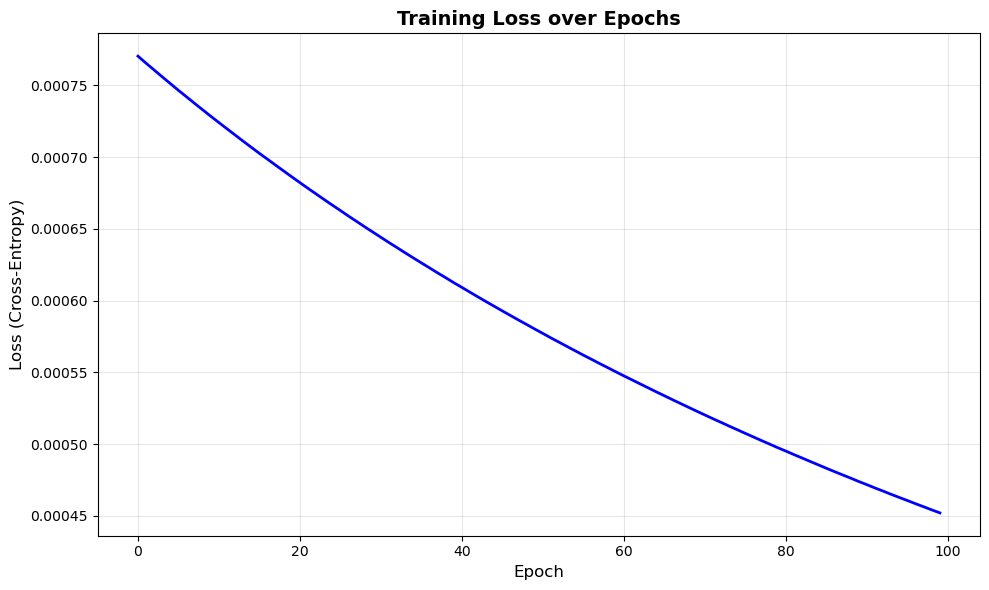

초기 손실: 0.000770
최종 손실: 0.000452
손실 감소율: 41.33%


In [10]:
plt.figure(figsize=(10, 6))
plt.plot(losses, linewidth=2, color='blue')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Cross-Entropy)', fontsize=12)
plt.title('Training Loss over Epochs', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"초기 손실: {losses[0]:.6f}")
print(f"최종 손실: {losses[-1]:.6f}")
print(f"손실 감소율: {(1 - losses[-1]/losses[0])*100:.2f}%")

## 10. 은닉 상태(Hidden State) 시각화

Part 1에서 배운 **은닉 상태 h_t**의 동작을 시각화합니다.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.98336023..0.9999928].


은닉 상태 (Hidden States) 분석:
은닉 상태 행렬 형태: (4, 3, 1)
(타임스텝: 4, 은닉 크기: 3)

h_1: [[ 0.9896233 ]
 [-0.98336023]
 [-0.97261286]] (||h||=1.7007)
h_2: [[0.99943864]
 [0.16989973]
 [0.9999928 ]] (||h||=1.4240)
h_3: [[0.68749607]
 [0.9997217 ]
 [0.86911726]] (||h||=1.4925)
h_4: [[-0.95808744]
 [ 0.9990255 ]
 [-0.8714797 ]] (||h||=1.6357)


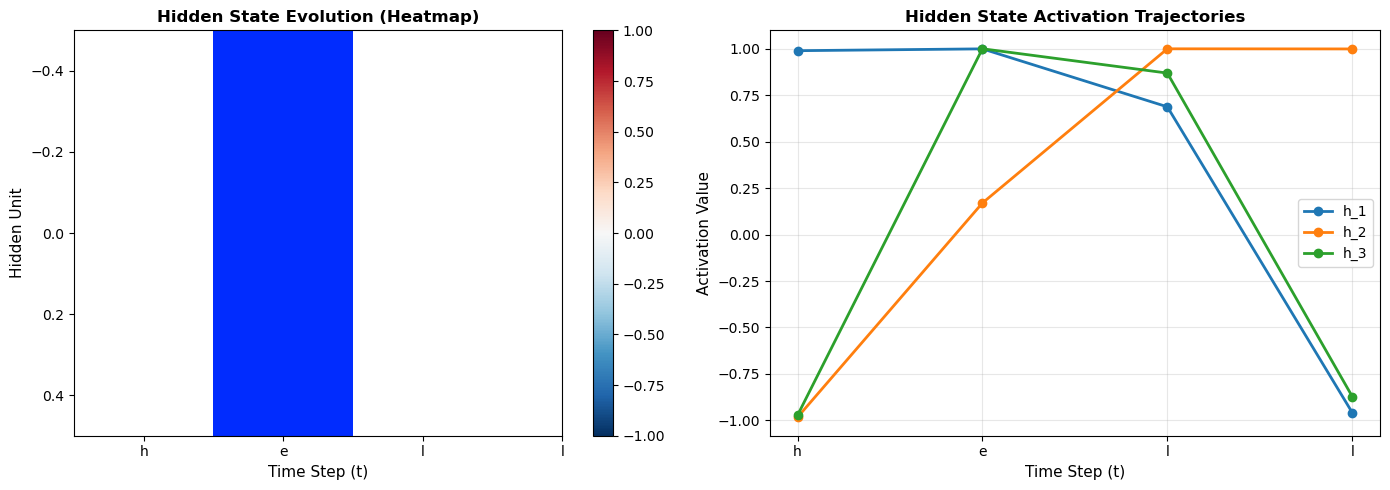

In [11]:
# 은닉 상태 추출
h_states = hidden_states[1:].detach().cpu().numpy()  # h_1부터 h_4까지

print("은닉 상태 (Hidden States) 분석:")
print(f"은닉 상태 행렬 형태: {h_states.shape}")
print(f"(타임스텝: {h_states.shape[0]}, 은닉 크기: {h_states.shape[1]})\n")

for t, h in enumerate(h_states):
    print(f"h_{t+1}: {h} (||h||={np.linalg.norm(h):.4f})")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히트맵
ax1 = axes[0]
im = ax1.imshow(h_states.T, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax1.set_xlabel('Time Step (t)', fontsize=11)
ax1.set_ylabel('Hidden Unit', fontsize=11)
ax1.set_title('Hidden State Evolution (Heatmap)', fontsize=12, fontweight='bold')
ax1.set_xticks(range(len(text)-1))
ax1.set_xticklabels([text[i] for i in range(len(text)-1)])
plt.colorbar(im, ax=ax1)

# 3D 플롯 (선택 사항)
ax2 = axes[1]
for i in range(hidden_size):
    ax2.plot(range(len(text)-1), h_states[:, i], marker='o', label=f'h_{i+1}', linewidth=2)
ax2.set_xlabel('Time Step (t)', fontsize=11)
ax2.set_ylabel('Activation Value', fontsize=11)
ax2.set_title('Hidden State Activation Trajectories', fontsize=12, fontweight='bold')
ax2.set_xticks(range(len(text)-1))
ax2.set_xticklabels([text[i] for i in range(len(text)-1)])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. 가중치 행렬 분석

학습된 가중치 행렬 분석

W_xh (입력→은닉): (3, 4)
  값 범위: [-2.1314, 1.9994]
  Frobenius norm: 4.7188

W_hh (은닉→은닉): (3, 3)
  값 범위: [-2.9005, 2.0480]
  Frobenius norm: 4.9286

W_hy (은닉→출력): (4, 3)
  값 범위: [-2.8105, 2.9841]
  Frobenius norm: 7.2691


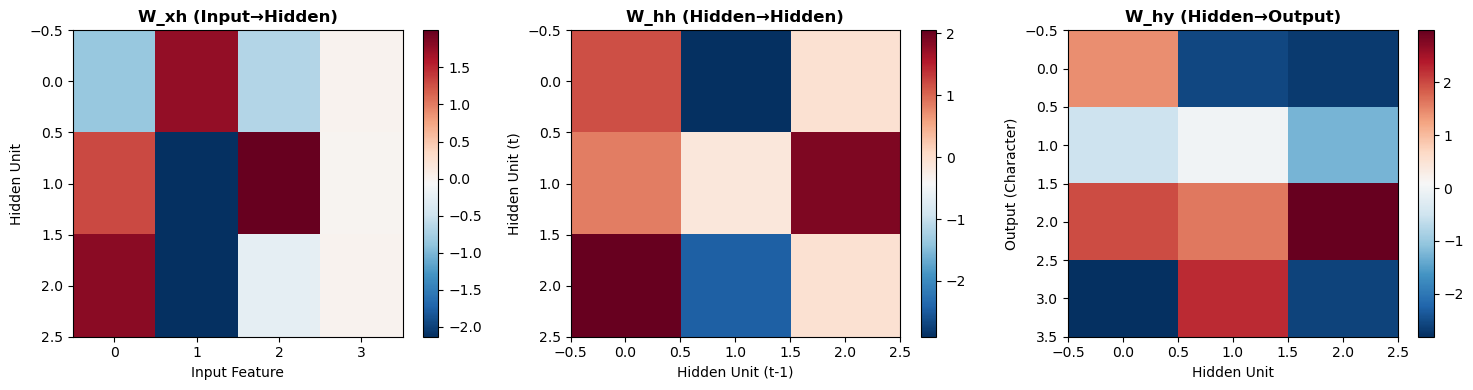

In [12]:
# 학습된 가중치 추출
W_xh = model.W_xh.detach().cpu().numpy()
W_hh = model.W_hh.detach().cpu().numpy()
W_hy = model.W_hy.detach().cpu().numpy()

print("="*60)
print("학습된 가중치 행렬 분석")
print("="*60)

print(f"\nW_xh (입력→은닉): {W_xh.shape}")
print(f"  값 범위: [{W_xh.min():.4f}, {W_xh.max():.4f}]")
print(f"  Frobenius norm: {np.linalg.norm(W_xh):.4f}")

print(f"\nW_hh (은닉→은닉): {W_hh.shape}")
print(f"  값 범위: [{W_hh.min():.4f}, {W_hh.max():.4f}]")
print(f"  Frobenius norm: {np.linalg.norm(W_hh):.4f}")

print(f"\nW_hy (은닉→출력): {W_hy.shape}")
print(f"  값 범위: [{W_hy.min():.4f}, {W_hy.max():.4f}]")
print(f"  Frobenius norm: {np.linalg.norm(W_hy):.4f}")

# 가중치 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(W_xh, cmap='RdBu_r', aspect='auto')
axes[0].set_title('W_xh (Input→Hidden)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Input Feature')
axes[0].set_ylabel('Hidden Unit')
plt.colorbar(axes[0].images[0], ax=axes[0])

axes[1].imshow(W_hh, cmap='RdBu_r', aspect='auto')
axes[1].set_title('W_hh (Hidden→Hidden)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hidden Unit (t-1)')
axes[1].set_ylabel('Hidden Unit (t)')
plt.colorbar(axes[1].images[0], ax=axes[1])

axes[2].imshow(W_hy, cmap='RdBu_r', aspect='auto')
axes[2].set_title('W_hy (Hidden→Output)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Hidden Unit')
axes[2].set_ylabel('Output (Character)')
plt.colorbar(axes[2].images[0], ax=axes[2])

plt.tight_layout()
plt.show()

## 12. 타임스텝별 상세 분석

Part 1 이론의 "6.2 타임스텝 t=1: 입력 'h'" 같은 상세 분석을 수행합니다.

In [13]:
print("="*70)
print("각 타임스텝별 상세 분석 (Part 1 6.2절 재현)")
print("="*70)

for t in range(len(text)-1):
    print(f"\n{'='*70}")
    print(f"타임스텝 t={t+1}: 입력 '{text[t]}'")
    print(f"{'='*70}")
    
    # 입력
    x_t = X[t].cpu().numpy()
    print(f"입력 벡터 (One-Hot): {x_t}")
    
    # 은닉 상태
    h_t = hidden_states[t+1].squeeze().detach().cpu().numpy()
    print(f"은닉 상태 h_t: {h_t}")
    print(f"  ||h_t|| = {np.linalg.norm(h_t):.4f}")
    
    # 출력 로짓
    y_t = y_preds[t].detach().cpu().numpy()
    print(f"출력 로짓 y_t: {y_t}")
    
    # 소프트맥스 확률
    probs = nn.functional.softmax(torch.tensor(y_t, dtype=torch.float32), dim=0).numpy()
    print(f"소프트맥스 확률: {probs}")
    
    # 예측 문자
    pred_idx = np.argmax(y_t)
    target_idx = Y_indices[t]
    print(f"\n예측: '{idx_to_char[pred_idx]}' (점수={y_t[pred_idx]:.4f})")
    print(f"정답: '{idx_to_char[target_idx]}' (점수={y_t[target_idx]:.4f})")
    print(f"정확도: {'✓ 맞음' if pred_idx == target_idx else '✗ 틀림'}")

각 타임스텝별 상세 분석 (Part 1 6.2절 재현)

타임스텝 t=1: 입력 'h'
입력 벡터 (One-Hot): [0. 1. 0. 0.]
은닉 상태 h_t: [ 0.9896233  -0.98336023 -0.97261286]
  ||h_t|| = 1.7007
출력 로짓 y_t: [ 7.297772   -1.2067338  -0.83892167 -1.7229095 ]
소프트맥스 확률: [9.99384284e-01 2.02428870e-04 2.92422803e-04 1.20809294e-04]

예측: 'e' (점수=7.2978)
정답: 'e' (점수=7.2978)
정확도: ✓ 맞음

타임스텝 t=2: 입력 'e'
입력 벡터 (One-Hot): [1. 0. 0. 0.]
은닉 상태 h_t: [0.99943864 0.16989973 0.9999928 ]
  ||h_t|| = 1.4240
출력 로짓 y_t: [-0.9530395 -3.7368283  6.9373827 -4.2813277]
소프트맥스 확률: [3.7415771e-04 2.3124398e-05 9.9958926e-01 1.3415219e-05]

예측: 'l' (점수=6.9374)
정답: 'l' (점수=6.9374)
정확도: ✓ 맞음

타임스텝 t=3: 입력 'l'
입력 벡터 (One-Hot): [0. 0. 1. 0.]
은닉 상태 h_t: [0.68749607 0.9997217  0.86911726]
  ||h_t|| = 1.4925
출력 로짓 y_t: [-3.1671572 -3.4245267  7.276234  -1.2024964]
소프트맥스 확률: [2.9132641e-05 2.2521946e-05 9.9974054e-01 2.0778851e-04]

예측: 'l' (점수=7.2762)
정답: 'l' (점수=7.2762)
정확도: ✓ 맞음

타임스텝 t=4: 입력 'l'
입력 벡터 (One-Hot): [0. 0. 1. 0.]
은닉 상태 h_t: [-0.95808744  0.9990255  -0.

## 13. Part 1 주요 개념 정리

### ✓ 학습한 개념

1. **RNN의 필요성**
   - 기존 신경망은 입출력이 고정
   - RNN은 가변 길이 시퀀스 처리 가능

2. **Vanilla RNN 구조**
   - 3개의 가중치 행렬: $W_{xh}$, $W_{hh}$, $W_{hy}$
   - 모든 타임스텝에서 동일한 가중치 공유

3. **순전파 (Forward Pass)**
   $$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t)$$
   $$y_t = W_{hy} h_t$$

4. **역전파 Through Time (BPTT)**
   - 각 타임스텝에서 그래디언트 계산
   - 모든 타임스텝의 그래디언트를 합산하여 가중치 업데이트

5. **은닉 상태의 역할**
   - 이전 정보를 압축하여 저장
   - 타임스텝이 길어질수록 그래디언트 소실 위험

###  실험 결과

- **훈련 데이터**: "hello" (4개의 문자)
- **최종 정확도**: {final_accuracy:.2%}
- **모델 파라미터**: $W_{xh}$ {W_xh.shape}, $W_{hh}$ {W_hh.shape}, $W_{hy}$ {W_hy.shape}

---
# 딥러닝 실습 (RUNPOD 4090)
---

In [14]:
!pip install konlpy

!apt update

!apt install -y openjdk-17-jdk

'apt'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.
'apt'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


In [16]:
from konlpy.tag import Okt
okt = Okt()

import pandas as pd
import re
df = pd.read_csv('./daum_movie_review.csv')
df['target'] = df['rating'].apply(lambda x : 1 if x>0.5 else 0)
df['clean'] = df['review'].apply(lambda x : re.sub(r'[^가-힣\s]','',x) )      

In [17]:
df['clean'][0]

'돈 들인건 티가 나지만 보는 내내 하품만'

In [18]:
okt = Okt()
def kor_tokenizer(text):    
    return [
        word for word, pos in okt.pos(text,stem=True) 
            if pos in ['Noun','Verb','Adjective'] and len(word) >=2        
           ]

In [19]:
# 시간순서가 중요하므로 사용할수 없음
# from sklearn.feature_extraction.text import TfidfVectorizer
# tfidf = TfidfVectorizer(tokenizer=kor_tokenizer,max_features=10000)
# x = tfidf.fit_transform(df['clean'])

In [20]:
kor_tokenizer(df['clean'][0]),kor_tokenizer(df['clean'][1])

(['들이다', '보다', '내내', '하품'],
 ['몰입', '하다', '없다', '어렵다', '생각', '하다', '필요없다', '전투', '참여', '이남'])

In [21]:
# 단어사전 구축
from collections import Counter
vocab = Counter()
for text in df['clean']:
    vocab.update(kor_tokenizer(text))

In [22]:
# 10000개의 단어로만 구성
vocab_size = 10000
word_to_index = {
    word:idx+2 for idx, (word,seq) in enumerate(vocab.most_common(vocab_size))
}
word_to_index['<PAD>'] = 0
word_to_index['<UNK>'] = 1

def word2Sequence(text):
    return [word_to_index.get(word,1) for word in kor_tokenizer(text)]   

In [23]:
kor_tokenizer(df['clean'][0])

['들이다', '보다', '내내', '하품']

In [24]:
index_to_word = {idx : word for word, idx in word_to_index.items()}
index_to_word.get(345)

'들이다'

In [25]:
# padding
import torch
from torch.nn.utils.rnn import pad_sequence
x1 = word2Sequence(df['clean'][0])
x2 = word2Sequence(df['clean'][1])
x1_tensor = torch.LongTensor(x1)
x2_tensor = torch.LongTensor(x2)
print(x1_tensor,x2_tensor)
pad_sequence([x1_tensor,x2_tensor], batch_first=True, padding_value=0)

tensor([345,   4, 147, 731]) tensor([ 123,    2,    7,  453,   16,    2,  464, 1692, 2089, 3174])


tensor([[ 345,    4,  147,  731,    0,    0,    0,    0,    0,    0],
        [ 123,    2,    7,  453,   16,    2,  464, 1692, 2089, 3174]])

In [26]:
MAX_LEN = 500
def padding(texts):
    result = []
    for text in texts:
        text = word2Sequence(text)[:MAX_LEN]
        text = torch.LongTensor(text)
        result.append(text)
    return pad_sequence(result,batch_first=True, padding_value=0)
    
padding(df['clean'])        

tensor([[ 345,    4,  147,  ...,    0,    0,    0],
        [ 123,    2,    7,  ...,    0,    0,    0],
        [1307,  102,  372,  ...,    0,    0,    0],
        ...,
        [  64,    3,   80,  ...,    0,    0,    0],
        [ 228,  234, 1744,  ...,    0,    0,    0],
        [  66,  304,  334,  ...,    0,    0,    0]])

---
# [3교시]
runpod 4090 사용
---

In [43]:
!pip install konlpy
!apt update
!apt install -y openjdk-17-jdk
!pip install pandas

'apt'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.
'apt'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


In [44]:
!pip uninstall -y numpy scipy scikit-learn
!pip install numpy==1.26.4
!pip install scipy==1.11.4
!pip install scikit-learn==1.3.2

Found existing installation: numpy 2.1.3
Uninstalling numpy-2.1.3:
  Successfully uninstalled numpy-2.1.3
Found existing installation: scipy 1.15.3
Uninstalling scipy-1.15.3:
  Successfully uninstalled scipy-1.15.3
Found existing installation: scikit-learn 1.5.2
Uninstalling scikit-learn-1.5.2:
  Successfully uninstalled scikit-learn-1.5.2


You can safely remove it manually.
You can safely remove it manually.


  Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl.metadata (61 kB)
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ------------------- -------------------- 7.9/15.8 MB 44.5 MB/s eta 0:00:01
   ---------------------------------------- 15.8/15.8 MB 39.9 MB/s  0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
catboost 1.2.8 requires scipy, which is not installed.
gensim 4.4.0 requires scipy>=1.7.0, which is not installed.
imbalanced-learn 0.14.1 requires scikit-learn<2,>=1.4.2, which is not installed.
imbalanced-learn 0.14.1 requires scipy<2,>=1.11.4, which is not installed.
lightgbm 4.6.0 requires scipy, which is not installed.
xgboost 2.1.3 requires scipy, which is not installed.


   ---------------------------------------- 0.0/44.1 MB ? eta -:--:--
   ----- ---------------------------------- 6.6/44.1 MB 33.6 MB/s eta 0:00:02
   ------------ --------------------------- 13.6/44.1 MB 32.9 MB/s eta 0:00:01
   ----------------------- ---------------- 25.4/44.1 MB 40.3 MB/s eta 0:00:01
   --------------------------------- ------ 36.4/44.1 MB 43.7 MB/s eta 0:00:01
   ---------------------------------------- 44.1/44.1 MB 41.9 MB/s  0:00:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3


error: uninstall-no-record-file

× Cannot uninstall scipy 1.15.3
╰─> The package's contents are unknown: no RECORD file was found for scipy.

hint: You might be able to recover from this via: pip install --force-reinstall --no-deps scipy==1.15.3


ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'c:\\miniconda\\envs\\ml_env\\lib\\site-packages\\scipy-1.15.3.dist-info\\METADATA'



In [45]:
from konlpy.tag import Okt
import pandas as pd
okt = Okt()

In [46]:
import re
import pandas as pd
import torch
import torch.nn as nn

from konlpy.tag import Okt
from collections import Counter
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# =========================
# 데이터 로드
# =========================
url = 'https://raw.githubusercontent.com/skn29teacher/skn29_lecture/main/data_nlp/daum_movie_review.csv'
df = pd.read_csv(url)

df['target'] = df['rating'].apply(lambda x : 1 if x > 0.5 else 0)

df['clean'] = df['review'].apply(
    lambda x : re.sub(r'[^가-힣\s]', '', str(x))
)

# =========================
# 토크나이저
# =========================
okt = Okt()

def kor_tokenizer(text):
    return [
        word for word, pos in okt.pos(text, stem=True)
        if pos in ['Noun', 'Verb', 'Adjective']
        and len(word) >= 2
    ]

# =========================
# 단어사전 구축
# =========================
vocab = Counter()

for text in df['clean']:
    vocab.update(kor_tokenizer(text))

vocab_size = 10000

word_to_index = {
    word: idx + 2
    for idx, (word, count)
    in enumerate(vocab.most_common(vocab_size))
}

word_to_index['<PAD>'] = 0
word_to_index['<UNK>'] = 1

index_to_word = {
    idx: word
    for word, idx in word_to_index.items()
}

# =========================
# 문장 -> 시퀀스
# =========================
def word2Sequence(text):
    return [
        word_to_index.get(word, 1)
        for word in kor_tokenizer(text)
    ]

# =========================
# Padding
# =========================
MAX_LEN = 500

def padding(texts):

    result = []

    for text in texts:

        seq = word2Sequence(text)

        # 최대 길이 제한
        seq = seq[:MAX_LEN]

        # tensor 변환
        seq = torch.LongTensor(seq)

        result.append(seq)

    return pad_sequence(
        result,
        batch_first=True,
        padding_value=0
    )

X = padding(df['clean'])

y = torch.FloatTensor(df['target'].values)

print(X.shape)
print(y.shape)

# =========================
# train test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================
# DataLoader
# =========================
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64
)

# =========================
# Device
# =========================
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print(device)

# =========================
# RNN 모델
# =========================
class RNNClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):

        # B L -> B L D
        x = self.embedding(x)

        # output : B L H
        # hidden : 1 B H
        output, hidden = self.rnn(x)

        # 마지막 hidden
        hidden = hidden.squeeze(0)

        logits = self.fc(hidden)

        return logits

# =========================
# 모델 생성
# =========================
model = RNNClassifier(
    vocab_size=vocab_size + 2,
    embedding_dim=128,
    hidden_dim=64
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

# =========================
# 학습
# =========================
EPOCHS = 5

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch).squeeze(1)

        loss = criterion(logits, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(
        f'Epoch {epoch+1} Loss : {total_loss/len(train_loader):.4f}'
    )

# =========================
# 평가
# =========================
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch).squeeze(1)

        pred = torch.sigmoid(logits) >= 0.5

        correct += (pred == y_batch).sum().item()

        total += y_batch.size(0)

print(f'Accuracy : {correct/total:.4f}')

# =========================
# 예측 함수
# =========================
def predict_sentiment(text):

    model.eval()

    seq = word2Sequence(text)

    seq = seq[:MAX_LEN]

    seq = torch.LongTensor(seq).unsqueeze(0).to(device)

    with torch.no_grad():

        logits = model(seq)

        prob = torch.sigmoid(logits)

    return prob.item()

# =========================
# 테스트
# =========================
text = "진짜 너무 재미있고 감동적인 영화였다"

score = predict_sentiment(text)

print(score)

if score >= 0.5:
    print("긍정")
else:
    print("부정")

torch.Size([14725, 106])
torch.Size([14725])
cpu
Epoch 1 Loss : 0.2109
Epoch 2 Loss : 0.1806
Epoch 3 Loss : 0.1802
Epoch 4 Loss : 0.1847
Epoch 5 Loss : 0.1846
Accuracy : 0.9569
0.8259919881820679
긍정


In [49]:
text = "지루하다"

score = predict_sentiment(text)

print(score)

if score >= 0.6:
    print("긍정")
else:
    print("부정")

0.45577865839004517
부정


In [47]:
import re
url = 'https://raw.githubusercontent.com/skn29teacher/skn29_lecture/main/data_nlp/daum_movie_review.csv'
df = pd.read_csv(url)
df['target'] = df['rating'].apply(lambda x : 1 if x>0.5 else 0)
df['clean'] = df['review'].apply(lambda x : re.sub(r'[^가-힣\s]','',x) )    

okt = Okt()
def kor_tokenizer(text):    
    return [
        word for word, pos in okt.pos(text,stem=True) 
            if pos in ['Noun','Verb','Adjective'] and len(word) >=2        
           ]

# 단어사전 구축
from collections import Counter
vocab = Counter()
for text in df['clean']:
    vocab.update(kor_tokenizer(text))

# 10000개의 단어로만 구성
vocab_size = 10000
word_to_index = {
    word:idx+2 for idx, (word,seq) in enumerate(vocab.most_common(vocab_size))
}
word_to_index['<PAD>'] = 0
word_to_index['<UNK>'] = 1

def word2Sequence(text):
    return [word_to_index.get(word,1) for word in kor_tokenizer(text)]    

index_to_word = {idx : word for word, idx in word_to_index.items()}
# padding
import torch
from torch.nn.utils.rnn import pad_sequence
x1 = word2Sequence(df['clean'][0])
x2 = word2Sequence(df['clean'][1])
x1_tensor = torch.LongTensor(x1)
x2_tensor = torch.LongTensor(x2)
print(x1_tensor,x2_tensor)
pad_sequence([x1_tensor,x2_tensor], batch_first=True, padding_value=0)

MAX_LEN = 50
def padding(texts):
    result = []
    for text in texts:
        text = word2Sequence(text)[:MAX_LEN]
        text = torch.LongTensor(text)
        result.append(text)
    return pad_sequence(result,batch_first=True, padding_value=0)
    
padding(df['clean'])  


tensor([345,   4, 147, 731]) tensor([ 123,    2,    7,  453,   16,    2,  464, 1692, 2089, 3174])


tensor([[ 345,    4,  147,  ...,    0,    0,    0],
        [ 123,    2,    7,  ...,    0,    0,    0],
        [1307,  102,  372,  ...,    0,    0,    0],
        ...,
        [  64,    3,   80,  ...,    0,    0,    0],
        [ 228,  234, 1744,  ...,    0,    0,    0],
        [  66,  304,  334,  ...,    0,    0,    0]])

In [48]:
# import pandas as pd
# # https://github.com/skn29teacher/skn29_lecture/blob/main/data_nlp/daum_movie_review.csv
# url = 'https://raw.githubusercontent.com/skn29teacher/skn29_lecture/main/data_nlp/daum_movie_review.csv'
# pd.read_csv(url)

---

# [4교시]

## LSTM이 뭐예요?

**LSTM(엘에스티엠)** 은 "긴 문장을 기억하는 인공지능"입니다.

예를 들어보겠습니다:

```
"나는 어제 서울에서 버스를 타고 강릉에 도착했다. 
강릉에서 3시간을 머물렀다. 
그리고 집으로 돌아왔다. 
내가 탔던 버스는 어떤 버스였나?"
```

이 질문에 답하려면 긴 문장 맨 앞의 **"버스"** 라는 말을 기억해야 합니다. 중간에 "강릉", "3시간" 같은 다른 정보들이 있지만, "버스"는 꼭 기억해야 하죠.

**LSTM은 이렇게 중요한 정보는 오래 기억하고, 불필요한 정보는 잊어버리는 신경망입니다.**

---

## LSTM의 핵심: 3가지 선택

LSTM은 매 순간마다 3가지를 선택합니다:

### 1. 지우기 (망각 게이트)
"이전에 기억한 것 중에서 뭘 지워야 하나?"

```
이전 기억: "나는 어제 서울에"

선택:
- "나는" → 지움 (뒤에서 안 나올 것 같음)
- "어제" → 지움 (언제 탔는지는 덜 중요)
- "서울에" → 기억 (도시 정보는 중요할 수도)

결과 기억: "서울에"
```

### 2. 받아들이기 (입력 게이트)
"새로 들어온 정보 중에서 뭘 기억해야 하나?"

```
새로 들어온 말: "버스를 타고"

선택:
- "버스를" → 기억! (매우 중요)
- "타고" → 기억 (동작 정보)

기억에 추가: "서울에" + "버스를 타고"
현재 기억: "서울에 버스를 타고"
```

### 3. 출력하기 (출력 게이트)
"지금 이 정보 중에서 뭘 사용해야 하나?"

```
현재 기억: "서울에 버스를 타고 강릉에"

필요한 것: 질문은 "버스가 뭐냐"

선택:
- "버스" → 필요! 꺼내기
- "강릉" → 지금은 필요 없음

출력: "버스"
```

---

## 아주 간단한 숫자 예제

우리가 1부터 10까지 세는 과정을 생각해봅시다:

1 → 2 → 3 → 4 → 5 → 6 → 7 → 8 → 9 → 10

**"10"이 나오면 그 전에 뭐가 있었지?"** 라고 물어봅시다.

### 일반 신경망 (RNN)이라면?
```
1에서 출발
× 0.9 → 0.9
× 0.9 → 0.81
× 0.9 → 0.729
× 0.9 → 0.6561
...
× 0.9 → 0.0000 (거의 0)

결과: 5단계 이상 전의 정보는 사라짐
```

### LSTM이라면?
```
1을 기억
+ 2 기억
+ 3 기억
+ 4 기억
+ 5 기억
+ 6 기억
+ 7 기억
+ 8 기억
+ 9 기억
→ 10 나왔을 때도 "1"을 여전히 기억할 수 있음!

(더하기 때문에 정보가 사라지지 않음)
```

**LSTM은 더하기를 사용하기 때문에 정보가 잘 사라지지 않습니다.**

---

## LSTM의 3가지 부분 (복잡하지 않게)

```
┌─────────────────────────────────┐
│         LSTM 한 칸              │
├─────────────────────────────────┤
│ ① 망각 게이트 (지우기)           │
│    "0 = 완전히 지움"            │
│    "1 = 완전히 유지"            │
├─────────────────────────────────┤
│ ② 입력 게이트 (받아들이기)       │
│    "0 = 무시"                  │
│    "1 = 다 받아들임"            │
├─────────────────────────────────┤
│ ③ 출력 게이트 (꺼내기)          │
│    "0 = 사용 안함"              │
│    "1 = 사용함"                │
└─────────────────────────────────┘
```

모든 게이트는 **0과 1 사이의 숫자**로 표현됩니다.

---

## 실제 예제: 문장 읽기

**문장**: "고양이가 쥐를 잡았다"

### 시점 1: "고양이가"
- 지우기: 없음 (처음이라 기억한 게 없음)
- 받아들이기: "고양이"를 기억! (0.9)
- 출력하기: 아직 문장이 끝나지 않았으니 조금만 (0.3)

현재 기억: "고양이" (약함)

### 시점 2: "쥐를"
- 지우기: "고양이"는 유지해야 함 (0.8) - 아직 필요할 수 있음
- 받아들이기: "쥐"를 추가 (0.7)
- 출력하기: 아직 끝 안 났으니 조금 (0.4)

현재 기억: "고양이" + "쥐" (약함)

### 시점 3: "잡았다"
- 지우기: 둘 다 유지 (1.0) - 중요함
- 받아들이기: "잡다"라는 동작 추가 (0.9)
- 출력하기: 문장 끝났으니 많이 (0.9)

최종 기억: "고양이가 쥐를 잡았다" (강함)

---

## LSTM이 필요한 이유: 간단한 비유

### 일반 신경망 (RNN)
전화 게임을 하는데, 사람이 많아질수록 메시지가 왜곡됨:

```
1번: "고양이가 쥐를 잡았다"
2번: "고양이가 쥐를... 뭔가"
3번: "고양이가... 뭔가..."
4번: "고양이... 뭔가..."
5번: "... 뭔가"
```

### LSTM
메모지에 중요한 단어를 써서 넘김:

```
1번: "고양이가 쥐를 잡았다" (메모: 중요한 것 = 고양이, 쥐, 잡음)
2번: "메모 보고 → 고양이가 쥐를 잡았다"
3번: "메모 보고 → 고양이가 쥐를 잡았다"
...
10번: "메모 보고 → 고양이가 쥐를 잡았다"
```

---

## 정리: LSTM의 3가지 특징

| 특징 | 설명 | 효과 |
|------|------|------|
| **선택적 기억** | 중요한 것만 기억, 불필요한 건 잊음 | 정보 집중 |
| **더하기 연산** | 정보를 더해서 누적 | 오래 기억 가능 |
| **게이트 제어** | 3개의 게이트로 세밀한 조절 | 유연한 학습 |

---

# LSTM PyTorch 실습

이 노트북은 LSTM의 핵심인 기억을 작은 예제로 직접 확인하는 실습입니다.

학습 목표
- LSTM이 시퀀스 정보를 어떻게 받는지 이해하기
- `nn.LSTM`으로 간단한 모델 만들기
- 긴 문맥에서 첫 정보를 기억하는지 확인하기
- 필요하면 `nn.RNN`과 비교해 보기

In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

device: cpu


## 1) 실습 문제

입력은 무작위 숫자 시퀀스입니다. 정답은 맨 처음 숫자입니다.

예를 들어 `[3, 8, 1, 4, 7]` 이 들어오면 정답은 `3`입니다.
이 문제는 뒤쪽 숫자들이 많아질수록 앞의 정보를 잘 기억해야 풀 수 있습니다.

In [51]:
def generate_memory_dataset(num_samples=4000, seq_len=12, vocab_size=5):
    x = torch.randint(0, vocab_size, (num_samples, seq_len), dtype=torch.long)
    y = x[:, 0].clone()
    return x, y

seq_len = 12
vocab_size = 5
train_x, train_y = generate_memory_dataset(num_samples=4000, seq_len=seq_len, vocab_size=vocab_size)
val_x, val_y = generate_memory_dataset(num_samples=1000, seq_len=seq_len, vocab_size=vocab_size)

train_loader = DataLoader(TensorDataset(train_x, train_y), batch_size=128, shuffle=True)

print(train_x.shape, train_y.shape)
print("예시 입력:", train_x[0].tolist())
print("정답:", train_y[0].item())

torch.Size([4000, 12]) torch.Size([4000])
예시 입력: [2, 2, 1, 4, 1, 0, 0, 4, 0, 3, 3, 4]
정답: 2


---

## 2) LSTM 모델 만들기

구조는 다음과 같습니다.

`Embedding -> LSTM -> Linear -> 분류`

마지막 시점의 출력을 사용해 처음 숫자를 맞히는 구조입니다.

In [52]:
class SequenceMemoryModel(nn.Module):
    def __init__(self, model_type="LSTM", vocab_size=10, emb_dim=32, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.model_type = model_type

        if model_type == "LSTM":
            self.rnn = nn.LSTM(emb_dim, hidden_dim, batch_first=True)
        elif model_type == "RNN":
            self.rnn = nn.RNN(emb_dim, hidden_dim, batch_first=True)
        else:
            raise ValueError(f"Unknown model_type: {model_type}")

        self.classifier = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        embedded = self.embedding(x)
        outputs, hidden = self.rnn(embedded)
        last_output = outputs[:, -1, :]
        logits = self.classifier(last_output)
        return logits, hidden

demo_model = SequenceMemoryModel(model_type="LSTM", vocab_size=vocab_size).to(DEVICE)
print(demo_model)

SequenceMemoryModel(
  (embedding): Embedding(5, 32)
  (rnn): LSTM(32, 64, batch_first=True)
  (classifier): Linear(in_features=64, out_features=5, bias=True)
)


---

## 3) LSTM 내부 출력 모양 확인

`nn.LSTM`은 마지막 출력뿐 아니라 hidden state와 cell state도 돌려줍니다.
이 셀은 실제 텐서 모양을 확인해서 개념과 연결해 보는 용도입니다.

In [53]:
sample_x = train_x[:2].to(DEVICE)
sample_embedding = demo_model.embedding(sample_x)
sample_outputs, (sample_h, sample_c) = demo_model.rnn(sample_embedding)

print("input shape:", sample_x.shape)
print("embedding shape:", sample_embedding.shape)
print("outputs shape:", sample_outputs.shape)
print("hidden shape:", sample_h.shape)
print("cell shape:", sample_c.shape)

input shape: torch.Size([2, 12])
embedding shape: torch.Size([2, 12, 32])
outputs shape: torch.Size([2, 12, 64])
hidden shape: torch.Size([1, 2, 64])
cell shape: torch.Size([1, 2, 64])


---

## 4) 학습 함수

아래 함수는 LSTM과 RNN을 같은 조건으로 학습시킵니다.
정확도도 함께 출력해서 두 모델을 비교할 수 있게 했습니다.

In [54]:
def accuracy(logits, target):
    pred = logits.argmax(dim=-1)
    return (pred == target).float().mean().item()

@torch.no_grad()
def evaluate(model, x, y, criterion):
    model.eval()
    x = x.to(DEVICE)
    y = y.to(DEVICE)
    logits, _ = model(x)
    loss = criterion(logits, y)
    acc = accuracy(logits, y)
    return loss.item(), acc

def train_model(model_type="LSTM", epochs=15, lr=0.01, hidden_dim=96, emb_dim=32):
    model = SequenceMemoryModel(model_type=model_type, vocab_size=vocab_size, emb_dim=emb_dim, hidden_dim=hidden_dim).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_acc = 0.0
        num_batches = 0

        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(DEVICE)
            batch_y = batch_y.to(DEVICE)

            optimizer.zero_grad()
            logits, _ = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item()
            running_acc += accuracy(logits, batch_y)
            num_batches += 1

        train_loss = running_loss / num_batches
        train_acc = running_acc / num_batches
        val_loss, val_acc = evaluate(model, val_x, val_y, criterion)
        history.append((train_loss, train_acc, val_loss, val_acc))

        print(f"[{model_type}] epoch {epoch:02d}/{epochs} | train loss {train_loss:.4f} acc {train_acc:.4f} | val loss {val_loss:.4f} acc {val_acc:.4f}")

    return model, history

---

## 5) LSTM 학습

이제 실제로 학습시켜 봅니다.
보통 이 과제에서는 LSTM이 RNN보다 긴 의존성을 더 안정적으로 기억합니다.

In [55]:
lstm_model, lstm_history = train_model(model_type="LSTM", epochs=15, lr=0.01, hidden_dim=96, emb_dim=32)

[LSTM] epoch 01/15 | train loss 1.6179 acc 0.1973 | val loss 1.6132 acc 0.2030
[LSTM] epoch 02/15 | train loss 1.6100 acc 0.2134 | val loss 1.6099 acc 0.2040
[LSTM] epoch 03/15 | train loss 1.6094 acc 0.1985 | val loss 1.6127 acc 0.1890
[LSTM] epoch 04/15 | train loss 1.6079 acc 0.2195 | val loss 1.6116 acc 0.2120
[LSTM] epoch 05/15 | train loss 1.6066 acc 0.2224 | val loss 1.6119 acc 0.2090
[LSTM] epoch 06/15 | train loss 1.6060 acc 0.2263 | val loss 1.6114 acc 0.2030
[LSTM] epoch 07/15 | train loss 1.4291 acc 0.3328 | val loss 0.9651 acc 0.4020
[LSTM] epoch 08/15 | train loss 1.0795 acc 0.4075 | val loss 0.9595 acc 0.3790
[LSTM] epoch 09/15 | train loss 0.9241 acc 0.4558 | val loss 0.7568 acc 0.5860
[LSTM] epoch 10/15 | train loss 0.6544 acc 0.6292 | val loss 0.6573 acc 0.6030
[LSTM] epoch 11/15 | train loss 0.6145 acc 0.6726 | val loss 0.4570 acc 0.7940
[LSTM] epoch 12/15 | train loss 0.1035 acc 0.9690 | val loss 0.0027 acc 1.0000
[LSTM] epoch 13/15 | train loss 0.0011 acc 1.0000 | 

---

## 6) 결과 확인

몇 개 샘플을 뽑아서 첫 숫자를 맞히는지 확인합니다.

In [56]:
with torch.no_grad():
    lstm_model.eval()
    sample_inputs = val_x[:8].to(DEVICE)
    sample_targets = val_y[:8].to(DEVICE)
    sample_logits, _ = lstm_model(sample_inputs)
    sample_predictions = sample_logits.argmax(dim=-1)

    for index in range(8):
        print(f"input={sample_inputs[index].tolist()} | target={sample_targets[index].item()} | pred={sample_predictions[index].item()}")

input=[0, 2, 3, 3, 0, 3, 2, 2, 3, 2, 1, 2] | target=0 | pred=0
input=[0, 1, 3, 4, 0, 0, 4, 1, 3, 2, 1, 0] | target=0 | pred=0
input=[1, 3, 2, 2, 0, 2, 2, 0, 4, 2, 4, 4] | target=1 | pred=1
input=[2, 3, 2, 4, 1, 0, 0, 2, 3, 0, 4, 2] | target=2 | pred=2
input=[1, 4, 3, 3, 1, 0, 2, 4, 3, 2, 0, 1] | target=1 | pred=1
input=[2, 3, 0, 3, 0, 4, 3, 2, 2, 3, 0, 2] | target=2 | pred=2
input=[3, 3, 4, 0, 4, 0, 0, 1, 1, 1, 4, 3] | target=3 | pred=3
input=[0, 2, 2, 3, 4, 0, 2, 1, 4, 0, 2, 1] | target=0 | pred=0


---

## 7) RNN과 비교해 보기

같은 문제를 `nn.RNN`으로도 학습해 보면 차이를 체감하기 쉽습니다.
실행 시간이 부담되면 이 셀은 건너뛰어도 됩니다.

In [57]:
rnn_model, rnn_history = train_model(model_type="RNN", epochs=15, lr=0.01, hidden_dim=96, emb_dim=32)

[RNN] epoch 01/15 | train loss 1.4501 acc 0.3022 | val loss 1.1249 acc 0.4080
[RNN] epoch 02/15 | train loss 1.1294 acc 0.3916 | val loss 1.1634 acc 0.3960
[RNN] epoch 03/15 | train loss 1.1386 acc 0.3916 | val loss 1.1432 acc 0.3840
[RNN] epoch 04/15 | train loss 1.1348 acc 0.3921 | val loss 1.1304 acc 0.4070
[RNN] epoch 05/15 | train loss 1.1271 acc 0.4019 | val loss 1.1305 acc 0.3990
[RNN] epoch 06/15 | train loss 1.1230 acc 0.4067 | val loss 1.1745 acc 0.4010
[RNN] epoch 07/15 | train loss 1.0315 acc 0.5254 | val loss 0.2883 acc 0.9420
[RNN] epoch 08/15 | train loss 0.1065 acc 0.9700 | val loss 0.0149 acc 0.9970
[RNN] epoch 09/15 | train loss 0.0068 acc 0.9998 | val loss 0.0024 acc 1.0000
[RNN] epoch 10/15 | train loss 0.0018 acc 1.0000 | val loss 0.0014 acc 1.0000
[RNN] epoch 11/15 | train loss 0.0012 acc 1.0000 | val loss 0.0010 acc 1.0000
[RNN] epoch 12/15 | train loss 0.0009 acc 1.0000 | val loss 0.0008 acc 1.0000
[RNN] epoch 13/15 | train loss 0.0007 acc 1.0000 | val loss 0.00

---

## 8) 마무리

이 실습에서 확인한 점
- LSTM은 긴 시퀀스에서도 정보를 더 잘 유지합니다.
- `nn.LSTM`은 `output`, `hidden state`, `cell state`를 함께 돌려줍니다.
- 같은 구조라도 RNN보다 LSTM이 기억 문제에 더 유리한 경우가 많습니다.

다음 단계로는 이 코드에 망각 게이트, 입력 게이트, 출력 게이트 수식을 연결해서 보면 좋습니다.

---

# [5교시]

# LSTM" 수식

## LSTM의 4가지 계산 (수식 포함)

LSTM은 매 시점 $t$에서 정확히 4가지를 계산합니다. 하나씩 봅시다.

### 계산 1: 망각 게이트 (지우기 선택)

**수식**:
$f_t = \sigma(W_f \cdot x_t + U_f \cdot h_{t-1} + b_f)$

**각 기호 설명**:
- $f_t$: 망각 게이트 (시간 $t$에서)
- $x_t$: 현재 입력 (새로 들어온 단어)
- $h_{t-1}$: 이전 시점의 출력 (이전 기억)
- $W_f, U_f, b_f$: 가중치들 (신경망이 학습하는 값)
- $\sigma$: 시그모이드 함수 (0과 1 사이로 압축)

**의미**:
입력 $x_t$와 이전 출력 $h_{t-1}$을 조합해서 "뭘 지울까"를 결정합니다.

**결과 범위**: 0 ~ 1
- 0에 가까움 = 완전히 지움
- 1에 가까움 = 완전히 유지

### 계산 2: 입력 게이트 (받아들이기 선택)

**수식**:
$i_t = \sigma(W_i \cdot x_t + U_i \cdot h_{t-1} + b_i)$

**의미**:
입력 $x_t$와 이전 출력 $h_{t-1}$을 조합해서 "뭘 기억할까"를 결정합니다.

**결과 범위**: 0 ~ 1
- 0에 가까움 = 무시
- 1에 가까움 = 다 받아들임

### 계산 3: 후보 정보 계산

**수식**:
$\tilde{c}_t = \tanh(W_c \cdot x_t + U_c \cdot h_{t-1} + b_c)$

**의미**:
새로 들어온 정보 중에서 "어떤 내용을 추가할 수 있을까"를 계산합니다.

**$\tanh$ 함수**:
- 입력을 -1과 1 사이로 압축
- 복잡한 것처럼 보이지만, 신경망이 정보를 어느 정도 강하게 할지 결정하는 함수일 뿐

**결과 범위**: -1 ~ 1

### 계산 4: 출력 게이트 (꺼내기 선택)

**수식**:
$o_t = \sigma(W_o \cdot x_t + U_o \cdot h_{t-1} + b_o)$

**의미**:
"지금 기억한 것 중에서 뭘 사용할까"를 결정합니다.

**결과 범위**: 0 ~ 1
- 0에 가까움 = 사용 안함
- 1에 가까움 = 사용함

---

## 기억 업데이트 (핵심!)

위의 4개 계산이 끝나면, 기억(셀 상태) $c_t$를 업데이트합니다:

**수식**:
$c_t = f_t \cdot c_{t-1} + i_t \cdot \tilde{c}_t$

**설명**:
- 첫 번째 부분 $f_t \cdot c_{t-1}$: 이전 기억에서 선택된 것만 유지
- 두 번째 부분 $i_t \cdot \tilde{c}_t$: 새 정보에서 선택된 것만 추가
- 두 부분을 **더하기**로 합칩니다

**예제**:
```
이전 기억 c_{t-1} = 2.0 (점수)
망각 게이트 f_t = 0.7 (70% 유지)
새 정보 후보 = 3.0
입력 게이트 i_t = 0.5 (50% 받아들임)

계산:
c_t = 0.7 × 2.0 + 0.5 × 3.0
c_t = 1.4 + 1.5
c_t = 2.9

결과: 새로운 기억은 2.9
```

---

## 최종 출력

**수식**:
$h_t = o_t \cdot \tanh(c_t)$

**설명**:
- 현재 기억 $c_t$를 $\tanh$로 정규화 (-1과 1 사이로)
- 출력 게이트 $o_t$로 일부만 선택
- 다음 시점으로 전달하는 값 $h_t$ 결정

---

## 완전한 한 시점의 계산 예제

**상황**: 문장 "고양이가 쥐를"을 읽는 중. 이제 다음 단어를 읽습니다.

**주어진 값**:
- 현재 입력 단어: "잡았다" (수치로: 2.5)
- 이전 출력: $h_{t-1} = 1.0$
- 이전 기억: $c_{t-1} = 3.0$ ("고양이", "쥐" 정보가 들어있음)

### 단계 1: 망각 게이트 계산

$f_t = \sigma(W_f \cdot 2.5 + U_f \cdot 1.0 + b_f)$

예시값:
$f_t = \sigma(0.3 \times 2.5 + 0.4 \times 1.0 - 0.2)$
$f_t = \sigma(0.75 + 0.4 - 0.2)$
$f_t = \sigma(0.95)$
$f_t \approx 0.72$ (72% 유지)

**의미**: 이전 기억을 72% 정도 유지합니다.

### 단계 2: 입력 게이트 계산

$i_t = \sigma(W_i \cdot 2.5 + U_i \cdot 1.0 + b_i)$

예시값:
$i_t = \sigma(0.4 \times 2.5 + 0.3 \times 1.0 + 0.1)$
$i_t = \sigma(1.0 + 0.3 + 0.1)$
$i_t = \sigma(1.4)$
$i_t \approx 0.80$ (80% 받아들임)

**의미**: 새 단어의 80%를 받아들입니다.

### 단계 3: 후보 정보 계산

$\tilde{c}_t = \tanh(W_c \cdot 2.5 + U_c \cdot 1.0 + b_c)$

예시값:
$\tilde{c}_t = \tanh(0.5 \times 2.5 + 0.2 \times 1.0 + 0.3)$
$\tilde{c}_t = \tanh(1.25 + 0.2 + 0.3)$
$\tilde{c}_t = \tanh(1.75)$
$\tilde{c}_t \approx 0.94$ (강한 신호)

**의미**: 새 단어 "잡았다"는 강한 신호(0.94)입니다.

### 단계 4: 기억 업데이트 (가장 중요!)

$c_t = f_t \cdot c_{t-1} + i_t \cdot \tilde{c}_t$
$c_t = 0.72 \times 3.0 + 0.80 \times 0.94$
$c_t = 2.16 + 0.752$
$c_t = 2.912$

**의미**:
- 이전 기억 3.0의 72% (2.16) 유지
- 새 정보 0.94의 80% (0.752) 추가
- 결과: 새로운 기억은 2.912

### 단계 5: 출력 게이트 계산

$o_t = \sigma(W_o \cdot 2.5 + U_o \cdot 1.0 + b_o)$

예시값:
$o_t = \sigma(0.35 \times 2.5 + 0.5 \times 1.0 - 0.1)$
$o_t = \sigma(0.875 + 0.5 - 0.1)$
$o_t = \sigma(1.275)$
$o_t \approx 0.78$ (78% 사용)

### 단계 6: 최종 출력

$h_t = o_t \cdot \tanh(c_t)$
$h_t = 0.78 \times \tanh(2.912)$
$h_t = 0.78 \times 0.994$
$h_t \approx 0.775$

**최종 결과**:
- 새로운 기억: $c_t = 2.912$ (다음 시점으로 전달)
- 새로운 출력: $h_t = 0.775$ (다음 계산 또는 최종 답변으로 사용)

---

## 기호 정리표

| 기호 | 의미 | 범위 |
|------|------|------|
| $f_t$ | 망각 게이트 | 0~1 |
| $i_t$ | 입력 게이트 | 0~1 |
| $o_t$ | 출력 게이트 | 0~1 |
| $\tilde{c}_t$ | 후보 정보 | -1~1 |
| $c_t$ | 셀 상태 (기억) | 임의 |
| $h_t$ | 출력 상태 | -1~1 |
| $\sigma$ | 시그모이드 함수 | 0~1로 변환 |
| $\tanh$ | 하이퍼볼릭 탄젠트 함수 | -1~1로 변환 |


## 왜 이렇게 복잡한가?

**간단하게 말하면**:
- 3개의 게이트로 **세밀한 제어** 가능
- **더하기**로 정보 손실 최소화
- 각 가중치는 신경망이 **학습**하면서 최적화

In [58]:
import torch
import torch.nn as nn
torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else 'cpu'
print(f'device : {device}')

device : cpu


LSTM은 한 시점 $t$에서 아래 4가지를 계산합니다.

- 망각 게이트: $f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f)$
- 입력 게이트: $i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i)$
- 후보 정보: $c̃_t = \tanh(W_c x_t + U_c h_{t-1} + b_c)$
- 출력 게이트: $o_t = \sigma(W_o x_t + U_o h_{t-1} + b_o)$

그리고 기억과 출력은 다음처럼 계산합니다.

- $c_t = f_t \cdot c_{t-1} + i_t \cdot c̃_t$
- $h_t = o_t \cdot \tanh(c_t)$

In [59]:
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

def step_lstm_manual(x_t, h_prev, c_prev, weights):
    W_f, U_f, b_f = weights['W_f'], weights['U_f'], weights['b_f']
    W_i, U_i, b_i = weights['W_i'], weights['U_i'], weights['b_i']
    W_c, U_c, b_c = weights['W_c'], weights['U_c'], weights['b_c']
    W_o, U_o, b_o = weights['W_o'], weights['U_o'], weights['b_o']

    f_t = sigmoid(W_f @ x_t + U_f @ h_prev + b_f)
    i_t = sigmoid(W_i @ x_t + U_i @ h_prev + b_i)
    c_hat_t = torch.tanh(W_c @ x_t + U_c @ h_prev + b_c)
    o_t = sigmoid(W_o @ x_t + U_o @ h_prev + b_o)
    c_t = f_t * c_prev + i_t * c_hat_t
    h_t = o_t * torch.tanh(c_t)

    return {
        'f_t': f_t,
        'i_t': i_t,
        'c_hat_t': c_hat_t,
        'o_t': o_t,
        'c_t': c_t,
        'h_t': h_t,
    }

### 한 시점 계산을 직접 해보기
 - 입력벡터는 2차원, 은닉상태도 2차원

In [60]:
x_t = torch.tensor([[2.5], [1.0]])
h_prev = torch.tensor([[1.0], [0.5]])
c_prev = torch.tensor([[3.0], [2.0]])

weights = {
    'W_f': torch.tensor([[0.3, -0.1], [0.2, 0.4]]),
    'U_f': torch.tensor([[0.4, 0.2], [-0.1, 0.3]]),
    'b_f': torch.tensor([[ -0.2], [0.1]]),
    'W_i': torch.tensor([[0.4, 0.1], [0.3, -0.2]]),
    'U_i': torch.tensor([[0.3, 0.2], [0.1, 0.4]]),
    'b_i': torch.tensor([[0.1], [0.0]]),
    'W_c': torch.tensor([[0.5, -0.2], [0.2, 0.3]]),
    'U_c': torch.tensor([[0.2, 0.1], [0.3, -0.1]]),
    'b_c': torch.tensor([[0.3], [-0.2]]),
    'W_o': torch.tensor([[0.35, 0.05], [0.25, -0.15]]),
    'U_o': torch.tensor([[0.5, 0.1], [0.2, 0.3]]),
    'b_o': torch.tensor([[-0.1], [0.2]]),
}

result = step_lstm_manual(x_t, h_prev, c_prev, weights)
for name, value in result.items():
    print(name)
    print(value)
    print()

f_t
tensor([[0.7211],
        [0.7408]])

i_t
tensor([[0.8320],
        [0.7006]])

c_hat_t
tensor([[0.9217],
        [0.6911]])

o_t
tensor([[0.7982],
        [0.7359]])

c_t
tensor([[2.9302],
        [1.9657]])

h_t
tensor([[0.7936],
        [0.7076]])



## 셀 상태와 출력의 차이 보기

$c_t$ 는 기억 그 자체에 가깝고, $h_t$ 는 그 기억을 일부 꺼내 쓴 결과입니다.

아래 셀은 같은 값에서 $tanh(c_t)$ 와 $o_t$ 가 어떻게 결합되는지 보여줍니다.

In [62]:
c_t = result['c_t']
o_t = result['o_t']
tanh_c_t = torch.tanh(c_t)
h_t = result['h_t']

print('tanh(c_t)')
print(tanh_c_t)
print()
print('o_t * tanh(c_t)')
print(o_t * tanh_c_t)
print()
print('h_t')
print(h_t)

tanh(c_t)
tensor([[0.9943],
        [0.9615]])

o_t * tanh(c_t)
tensor([[0.7936],
        [0.7076]])

h_t
tensor([[0.7936],
        [0.7076]])


##  PyTorch `nn.LSTMCell`과 비교

같은 가중치를 `nn.LSTMCell`에 넣으면 동일한 결과가 나와야 합니다.
이 비교로 수식과 구현이 같은지 확인합니다.

In [63]:
input_size = 2
hidden_size = 2
cell = nn.LSTMCell(input_size=input_size, hidden_size=hidden_size).to(DEVICE)

with torch.no_grad():
    weight_ih = torch.cat([
        weights['W_i'],
        weights['W_f'],
        weights['W_c'],
        weights['W_o'],
    ], dim=0)
    weight_hh = torch.cat([
        weights['U_i'],
        weights['U_f'],
        weights['U_c'],
        weights['U_o'],
    ], dim=0)
    bias_ih = torch.cat([
        weights['b_i'].squeeze(1),
        weights['b_f'].squeeze(1),
        weights['b_c'].squeeze(1),
        weights['b_o'].squeeze(1),
    ], dim=0)
    bias_hh = torch.zeros_like(bias_ih)

    cell.weight_ih.copy_(weight_ih)
    cell.weight_hh.copy_(weight_hh)
    cell.bias_ih.copy_(bias_ih)
    cell.bias_hh.copy_(bias_hh)

x_input = x_t.T
h_input = h_prev.T
c_input = c_prev.T

h_cell, c_cell = cell(x_input, (h_input, c_input))

print('manual h_t')
print(h_t.T)
print()
print('lstmcell h_t')
print(h_cell)
print()
print('manual c_t')
print(c_t.T)
print()
print('lstmcell c_t')
print(c_cell)

manual h_t
tensor([[0.7936, 0.7076]])

lstmcell h_t
tensor([[0.7936, 0.7076]], grad_fn=<MulBackward0>)

manual c_t
tensor([[2.9302, 1.9657]])

lstmcell c_t
tensor([[2.9302, 1.9657]], grad_fn=<AddBackward0>)


##  여러 시점에 걸친 계산 보기

LSTM의 강점은 한 시점이 아니라 여러 시점을 지나도 기억을 더 안정적으로 유지하는 데 있습니다.
아래는 3개의 시퀀스 입력을 차례대로 넣어 `c_t`와 `h_t`가 어떻게 변하는지 보는 예제입니다.

In [64]:
sequence = [
    torch.tensor([[2.0], [1.0]]),
    torch.tensor([[1.5], [0.5]]),
    torch.tensor([[2.5], [1.0]]),
]

h_state = h_prev
c_state = c_prev

for step_index, x_step in enumerate(sequence, start=1):
    step_result = step_lstm_manual(x_step, h_state, c_state, weights)
    h_state = step_result['h_t']
    c_state = step_result['c_t']

    print(f'--- step {step_index} ---')
    print('x_t =', x_step.T)
    print('f_t =', step_result['f_t'].T)
    print('i_t =', step_result['i_t'].T)
    print('c_t =', step_result['c_t'].T)
    print('h_t =', step_result['h_t'].T)
    print()

--- step 1 ---
x_t = tensor([[2., 1.]])
f_t = tensor([[0.6900, 0.7211]])
i_t = tensor([[0.8022, 0.6682]])
c_t = tensor([[2.7711, 1.8666]])
h_t = tensor([[0.7625, 0.6777]])

--- step 2 ---
x_t = tensor([[1.5000, 0.5000]])
f_t = tensor([[0.6549, 0.6742]])
i_t = tensor([[0.7529, 0.6676]])
c_t = tensor([[2.4354, 1.5183]])
h_t = tensor([[0.6999, 0.6375]])

--- step 3 ---
x_t = tensor([[2.5000, 1.0000]])
f_t = tensor([[0.7021, 0.7542]])
i_t = tensor([[0.8231, 0.7058]])
c_t = tensor([[2.4626, 1.5918]])
h_t = tensor([[0.7642, 0.6740]])



##  왜 더하기가 중요한가

RNN처럼 계속 곱하기만 하면 값이 빠르게 작아질 수 있습니다.

LSTM은 $f_t$ * $c_{t-1}$ + $i_t$ * $c̃_t$ 형태로 기억을 더해서 오래 유지하기 쉽게 만듭니다.

In [65]:
decay = 0.9
value = torch.tensor(1.0)

print('단순 곱셈 누적 예시')
for i in range(1, 11):
    value = value * decay
    print(f'step {i}: {value.item():.6f}')

print()
print('LSTM식 더하기 예시')
memory = torch.tensor(1.0)
for i in range(1, 6):
    memory = 0.9 * memory + 0.2
    print(f'step {i}: {memory.item():.6f}')

단순 곱셈 누적 예시
step 1: 0.900000
step 2: 0.810000
step 3: 0.729000
step 4: 0.656100
step 5: 0.590490
step 6: 0.531441
step 7: 0.478297
step 8: 0.430467
step 9: 0.387420
step 10: 0.348678

LSTM식 더하기 예시
step 1: 1.100000
step 2: 1.190000
step 3: 1.271000
step 4: 1.343900
step 5: 1.409510


## 핵심

- 각 게이트는 0과 1 사이 값으로 기억을 조절합니다.
- 셀 상태 $c_t$ 는 기억, $h_t$ 는 현재 출력입니다.
- 수식 계산과 $nn.LSTMCell$ 의 결과는 같은 구조를 가집니다.
- 더하기 기반 업데이트가 LSTM의 핵심입니다.

---

# [6교시]

## GRU vs LSTM
- gate 2개  필요하면 기억유지 아니면 갱신
    - Update gate
    - Reset gate

- gate 3개  : 단기기억 + 장기기억, 분리관리
    - Forget gate
    - Input gate
    - Output gate
    - state 관리
        - hidden state
        - cell state
- 성능
    - 실제로 차이가 많이나는 경우가 드묾
- 사용은
    - GRU
        - 데이터 적음, GPU 약할, 빠른결과, 실시간 추론
        - 감성분석, 간단한 쳇봇, Iot
    - LSTM
        - 긴 문맥, 복잡한 시계역, 장기의존성 중요
        - 음성인식, 번역, 금융시계열

- Baseline으로서 GRU를 이용해서 성능을 빠르게 확인
- 빠르게 GRU, 긴 문맥 LSTM, 최고성능... Transformer

## GRU MODEL

In [111]:
import torch.nn as nn

class GRUClassification(nn.Module):
    def __init__(self, vocab_size, embed_dim=128,hidden_dim = 64):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=0
        )
        self.gru = nn.GRU(
            input_size= embed_dim,
            hidden_size = hidden_dim,
            batch_first=True
        )
        self.fc = nn.Linear( hidden_dim , 1)
    def forward(self, x):
        x = self.embedding(x)
        output, hidden =self.gru(x)
        # return output,hidden
        # hidden shape  (num_layer, batch, hidden_dim)   (1, batch , 64)        
        x = self.fc(hidden[-1])  # 2 dim 이고 마지막 압축된 은닉층 정보로 분류
        return x

## Data

In [112]:
import  torch
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter

In [113]:
# url = 'https://github.com/skn29teacher/skn29_lecture/blob/main/data_nlp/daum_movie_review.csv'
import pandas as pd
url = 'https://raw.githubusercontent.com/skn29teacher/skn29_lecture/main/data_nlp/daum_movie_review.csv'
df = pd.read_csv(url)
sample_df = df.iloc[-1000:]

In [114]:
sample_df['target'] = sample_df['rating'].apply(lambda x : 1 if x>0.5 else 0)

# 한글만 남기기

In [115]:

import re
def clean_text(text):
    return re.sub(r'[^가-힣\s]', '', text).strip()
df['clean'] = df['review'].apply(lambda x : clean_text( x ) )

## 토큰화 : 숫자로변경하기위한 최소한의 단어들

In [116]:
#from konlpy.tag import Okt
# 공백을기준으로 분류
df['tokens'] = df['clean'].apply(lambda x : x.split() )

## 단어사전 구축하기

In [117]:
vocab_size = 10000
counter = Counter()
for tokens in df['tokens']:
    counter.update(tokens)
    
vocab = {
    '<PAD>' : 0,
    '<UNK>' : 1,
}    
for word, freq in counter.most_common(vocab_size):
    if len(word)>=2:
        vocab[word] = len(vocab)
print(f'단어수 : {len(vocab)}')

단어수 : 9712


In [118]:
vocab.items()

dict_items([('<PAD>', 0), ('<UNK>', 1), ('영화', 2), ('너무', 3), ('정말', 4), ('진짜', 5), ('그냥', 6), ('보고', 7), ('많이', 8), ('영화를', 9), ('연기', 10), ('영화가', 11), ('그리고', 12), ('있는', 13), ('영화는', 14), ('봤는데', 15), ('이런', 16), ('하는', 17), ('보는', 18), ('마지막', 19), ('재밌게', 20), ('좋은', 21), ('봤습니다', 22), ('스토리', 23), ('윤계상', 24), ('다시', 25), ('시간', 26), ('최고', 27), ('마동석', 28), ('감동', 29), ('이렇게', 30), ('없는', 31), ('재미있게', 32), ('눈물', 33), ('완전', 34), ('하지만', 35), ('역시', 36), ('많은', 37), ('눈물이', 38), ('함께', 39), ('내가', 40), ('봤어요', 41), ('보면', 42), ('최고의', 43), ('그래도', 44), ('연기가', 45), ('재미', 46), ('같은', 47), ('이게', 48), ('모두', 49), ('느낌', 50), ('하고', 51), ('내내', 52), ('근데', 53), ('없고', 54), ('대한', 55), ('배우들', 56), ('보세요', 57), ('조금', 58), ('어떻게', 59), ('마지막에', 60), ('다른', 61), ('없다', 62), ('솔직히', 63), ('영화입니다', 64), ('마블', 65), ('나름', 66), ('평점', 67), ('한국', 68), ('모르고', 69), ('영화의', 70), ('있고', 71), ('이건', 72), ('연기도', 73), ('한번', 74), ('영화다', 75), ('아주', 76), ('광주', 77), ('특히', 78), ('않고', 79)

---

# [7교시]

## 문장을 숫자로 & 패딩

In [119]:
['나는','호랑이를','사냥했다']
[10,250,222]

[10, 250, 222]

In [120]:
from torch.nn.utils.rnn import pad_sequence
# 문장을 sequence_length 만큰 자른다.
# padd_sequence에 일괄 적용

sequence_length = 20
df['tokens_convert'] = df['tokens'].apply(
    lambda tokens : torch.LongTensor([ vocab.get(token,1) for token in tokens][:sequence_length] )
)
X = pad_sequence(df['tokens_convert'], batch_first=True, padding_value=0)
X.shape
y = df['rating'].apply(lambda x : x > 0.5).astype(int).values
y = torch.FloatTensor(y)
X.shape, y.shape


(torch.Size([14725, 20]), torch.Size([14725]))

In [121]:
x_train,x_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [122]:
x_train_dataset = TensorDataset(x_train,y_train)
x_train_dataloader = DataLoader(x_train_dataset,batch_size=32,shuffle=True)

x_test_dataset = TensorDataset(x_test,y_test)
x_test_dataloader = DataLoader(x_test_dataset,batch_size=32)

# [8교시]

# 모델 생성

In [123]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = GRUClassification(len(vocab)).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

## 학습

In [124]:
EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for x_batch, y_batch in x_train_dataloader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        pred = model(x_batch).squeeze(-1)        
        loss = criterion(pred, y_batch)        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()        
    print(
        f'Epoch:{epoch+1} '
        f'Loss:{total_loss/len(x_train_dataloader):.4f}'
    )

Epoch:1 Loss:0.2025
Epoch:2 Loss:0.1705
Epoch:3 Loss:0.1299
Epoch:4 Loss:0.0920
Epoch:5 Loss:0.0655


In [130]:
model.eval()
with torch.no_grad():
    total_loss = 0
    for x_batch, y_batch in x_test_dataloader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        pred = model(x_batch).squeeze(-1)
        pred = torch.sigmoid(pred)
        print(pred, y_batch)
        break

tensor([0.9852, 0.9660, 0.9941, 0.9996, 0.9989, 0.9985, 0.9947, 0.4014, 0.9978,
        0.9994, 0.9996, 0.9932, 0.9994, 0.9996, 0.9997, 0.9994, 0.9998, 0.9990,
        0.9960, 0.9980, 0.9924, 0.9897, 0.9943, 0.9998, 0.9992, 0.9599, 0.9995,
        0.9949, 0.9945, 0.9994, 0.9952, 0.9991]) tensor([1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
